# BT4012 In-class Kaggle Competition 2026 - e1155727

Task: predict the probability that a Bitcoin transaction is illicit, scored by ROC AUC.
Train covers time steps 1 to 35, test covers 36 to 49, so the model has to generalise forward in time.

Decision log (choices made for this notebook, with reasons):

| decision | choice | reason |
|---|---|---|
| validation | time-based hold-out, train steps 1-27, validate 28-35 | mirrors the test setup where test steps come after all training steps |
| unlabelled rows | used only to build graph features, never as training rows | their label is unknown, but their features still describe the neighbourhood of labelled nodes |
| graph features | in/out/total degree + mean and max of neighbour features, label-free | test nodes have no labelled neighbours, so anything based on neighbour labels would not transfer |
| neighbour feature subset | top 30 features by univariate AUC on the training split | keeps the table manageable and focuses on features that already separate the classes |
| near-duplicate features | dropped for logistic regression and the MLP, kept for trees | collinearity hurts the linear and neural models, trees are unaffected |
| time-proxy features | dropped for every model (features whose per-step mean trends almost perfectly with time_step) | they encode when a transaction happened rather than what it looks like, so they take unseen values in the test period, same reason time_step itself is excluded |
| models | logistic regression, random forest, LightGBM, PyTorch MLP, rank-average blend | baseline from lectures, two tree ensembles, one neural net, then a simple blend |
| tuning | small manual grids scored on validation AUC | enough to show the effect of the main hyperparameters without a long search |
| final submissions | LightGBM alone and a rank-average blend of random forest + LightGBM | the two were tied on validation, the blend of two different tree models is kept as the more robust option for a drifting test period |
| drift experiments | adversarial validation, removal of the most period-specific features, stronger regularisation, recency weighting, blends | the first public score (0.9496) sat far below validation (0.9976), so the test period drifts more than the validation block did and only the leaderboard can measure what helps |

AI assistance: Claude Code was used as a coding assistant for boilerplate, debugging and documentation.
All modelling decisions above were made by the student and are explained in the report.

In [1]:
import os
import random
import time
import itertools

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore', message='.*eval_set.*')  # eval_set still works in this lightgbm version, the notice just clutters the output

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# reproducibility --> same seed for numpy, python and torch
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

DEVICE = torch.device('cpu')  # small tabular data, cpu is enough and fully reproducible
# torch, scikit-learn and lightgbm each ship their own openmp runtime on macos --> keeping torch single threaded avoids a deadlock between them
torch.set_num_threads(1)
DATA_DIR = 'data'
OUT_DIR = 'outputs'
SUB_DIR = 'submissions'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SUB_DIR, exist_ok=True)

# validation rule --> everything before this step is train, this step onwards is validation
VALID_START = 28

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## 1. Load data and sanity checks

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
edges_df = pd.read_csv(os.path.join(DATA_DIR, 'txs_edgelist.csv'))
sample_sub_df = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

raw_features = [c for c in train_df.columns if c.startswith('feat_')]
output_feature = 'label'

print('train', train_df.shape, '| test', test_df.shape, '| edges', edges_df.shape)
print('raw features -->', len(raw_features))
print('train time steps -->', train_df.time_step.min(), 'to', train_df.time_step.max())
print('test time steps  -->', test_df.time_step.min(), 'to', test_df.time_step.max())
print('missing feature values -->', int(train_df[raw_features].isna().sum().sum() + test_df[raw_features].isna().sum().sum()))
print('submission index matches test -->', (sample_sub_df['index'].values == test_df['index'].values).all())
print(train_df[output_feature].value_counts(dropna=False).rename({0.0: 'licit', 1.0: 'illicit'}))

train (141772, 168) | test (15329, 168) | edges (234355, 2)
raw features --> 165
train time steps --> 1 to 35
test time steps  --> 36 to 49
missing feature values --> 0
submission index matches test --> True
label
NaN        110537
licit       27591
illicit      3644
Name: count, dtype: int64


In [3]:
# only labelled rows can be used for supervised training
labelled_df = train_df[train_df[output_feature].notna()].copy()
labelled_df[output_feature] = labelled_df[output_feature].astype(int)
unlabelled_df = train_df[train_df[output_feature].isna()].copy()
print('labelled -->', len(labelled_df), '| unlabelled -->', len(unlabelled_df))
print('illicit rate among labelled --> {:.3f}'.format(labelled_df[output_feature].mean()))

labelled --> 31235 | unlabelled --> 110537
illicit rate among labelled --> 0.117


## 2. Exploratory data analysis

### 2.1 Labels over time

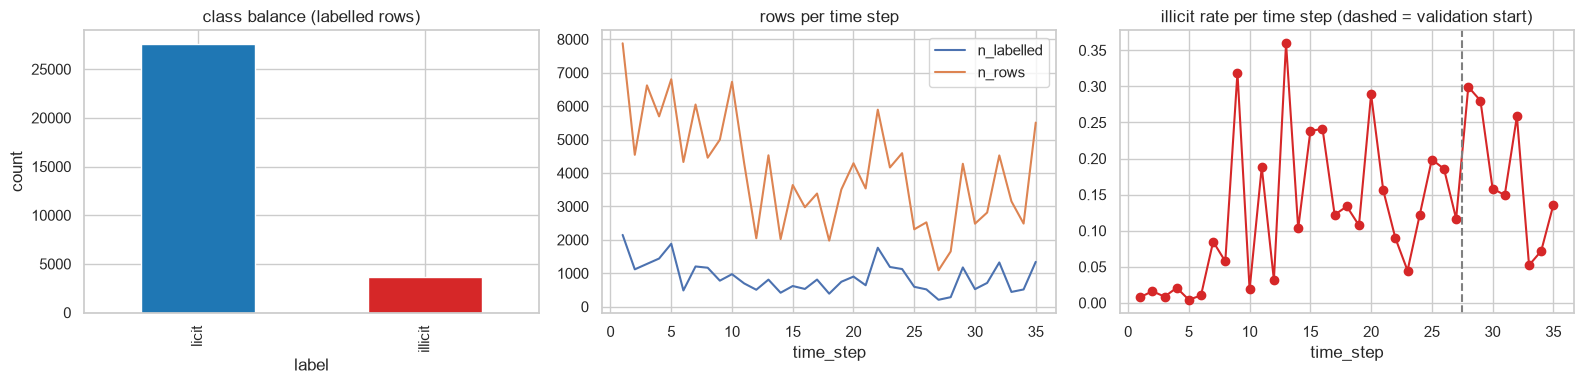

,n_rows,n_labelled,n_illicit,illicit_rate,unlabelled_share
count,35.000,35.000,35.000,35.000,35.000
mean,4050.629,892.429,104.114,0.134,0.784
std,1648.478,464.425,92.884,0.102,0.048
min,1089.000,206.000,5.000,0.004,0.701
25%,2669.500,520.500,27.000,0.048,0.747
50%,4275.000,778.000,85.000,0.122,0.790
75%,4794.000,1180.500,134.000,0.193,0.820
max,7880.000,2147.000,342.000,0.360,0.888


In [4]:
step_df = train_df.groupby('time_step').agg(
    n_rows=('txId', 'size'),
    n_labelled=(output_feature, 'count'),
    n_illicit=(output_feature, 'sum'))
step_df['illicit_rate'] = step_df.n_illicit / step_df.n_labelled
step_df['unlabelled_share'] = 1 - step_df.n_labelled / step_df.n_rows

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labelled_df[output_feature].value_counts().rename({0: 'licit', 1: 'illicit'}).plot(kind='bar', ax=axes[0], color=['tab:blue', 'tab:red'])
axes[0].set_title('class balance (labelled rows)')
axes[0].set_ylabel('count')
step_df[['n_labelled', 'n_rows']].plot(ax=axes[1])
axes[1].set_title('rows per time step')
step_df['illicit_rate'].plot(ax=axes[2], marker='o', color='tab:red')
axes[2].axvline(VALID_START - 0.5, ls='--', color='grey')
axes[2].set_title('illicit rate per time step (dashed = validation start)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_labels_over_time.png'), bbox_inches='tight')
plt.show()
step_df.describe().round(3)

The illicit rate jumps around a lot between time steps, which already hints that a random split would
give an optimistic estimate. The validation block (steps 28 to 35) is drawn with the dashed line.

### 2.2 Univariate signal of each feature

Each feature is scored by its own ROC AUC against the label. Only the training part of the split
(steps 1 to 27) is used for this ranking so that the validation steps stay untouched for model selection.
The ranking is reused later to pick which features get neighbour aggregates.

In [5]:
split_train_df = labelled_df[labelled_df.time_step < VALID_START]

def univariate_auc(df, features, target):
    rows = []
    for f in features:
        auc = metrics.roc_auc_score(df[target], df[f])
        rows.append((f, auc, abs(auc - 0.5)))
    return pd.DataFrame(rows, columns=['feature', 'auc', 'strength']).sort_values('strength', ascending=False).reset_index(drop=True)

uni_auc_df = univariate_auc(split_train_df, raw_features, output_feature)
uni_auc_df.to_csv(os.path.join(OUT_DIR, 'univariate_auc.csv'), index=False)
top_features = uni_auc_df.feature.head(30).tolist()
print('strongest single features')
uni_auc_df.head(10).round(3)

strongest single features


,feature,auc,strength
0,feat_53,0.107,0.393
1,feat_55,0.115,0.385
2,feat_90,0.137,0.363
3,feat_47,0.147,0.353
4,feat_41,0.148,0.352
5,feat_29,0.149,0.351
6,feat_23,0.149,0.351
7,feat_66,0.151,0.349
8,feat_60,0.151,0.349
9,feat_49,0.153,0.347


### 2.3 Descriptive statistics

Mean and standard deviation are compared with their robust counterparts (median, MAD).
The big gaps between them, together with the skew and kurtosis values, show that most features are heavy tailed.

In [6]:
desc_feats = top_features[:10]
desc_df = labelled_df[desc_feats].describe().loc[['mean', 'std', '50%', 'min', 'max']].T
desc_df = desc_df.rename(columns={'50%': 'median'})
desc_df['mad'] = [stats.median_abs_deviation(labelled_df[f]) for f in desc_feats]
desc_df['skew'] = labelled_df[desc_feats].skew()
desc_df['kurtosis'] = labelled_df[desc_feats].kurtosis()
desc_df.round(3).to_csv(os.path.join(OUT_DIR, 'descriptive_stats.csv'))
desc_df.round(3)

,mean,std,median,min,max,mad,skew,kurtosis
feat_53,1.022,1.530,0.481,-0.488,6.333,0.969,0.631,-1.035
feat_55,0.852,1.516,0.287,-0.468,6.430,0.754,1.101,0.088
feat_90,0.548,1.509,-0.224,-0.694,6.506,0.471,0.915,-0.690
feat_47,0.338,1.474,-0.241,-0.243,10.996,0.002,3.945,18.094
feat_41,0.346,1.554,-0.237,-0.239,16.683,0.002,4.926,32.959
feat_29,0.573,2.318,-0.149,-0.149,16.196,0.000,5.273,31.458
feat_23,0.573,2.318,-0.149,-0.149,16.195,0.000,5.273,31.455
feat_66,0.706,2.363,-0.163,-0.163,15.864,0.000,4.777,26.816
feat_60,0.706,2.363,-0.163,-0.163,15.864,0.000,4.777,26.817
feat_49,0.294,1.455,-0.235,-0.236,11.186,0.001,4.210,20.129


### 2.4 Distribution of the strongest features by class

A signed log transform is used for the x axis so that the heavy tails do not squash the plot.

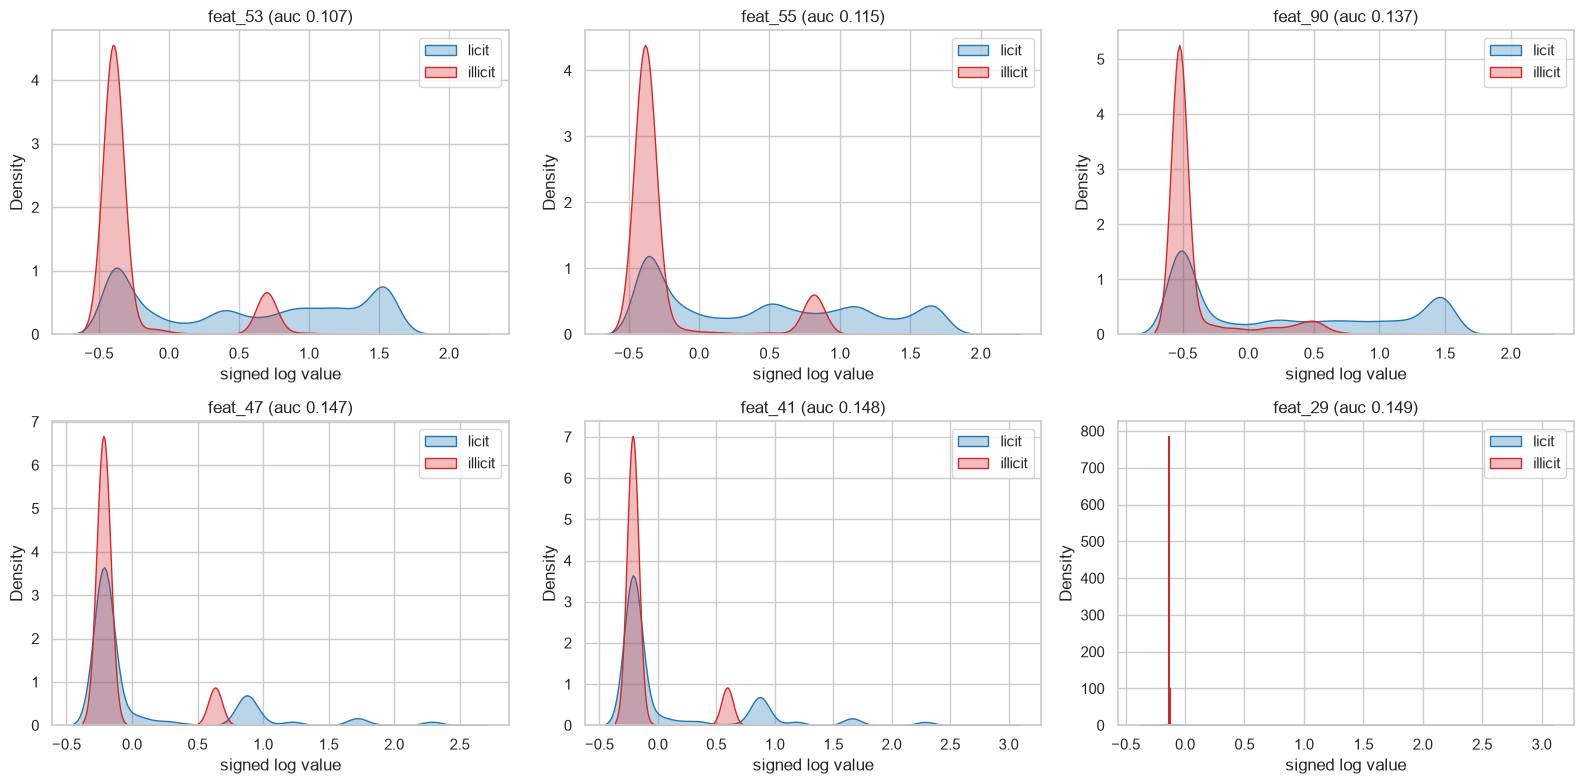

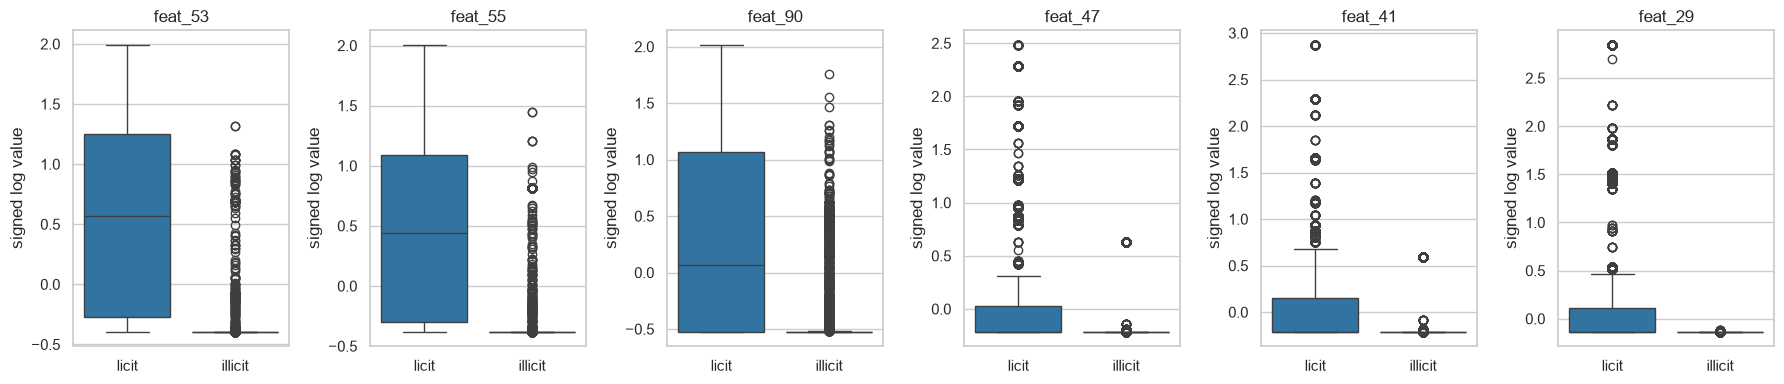

In [7]:
def signed_log(x):
    # keeps the sign, compresses the tails --> useful for plotting and for the linear and neural models
    return np.sign(x) * np.log1p(np.abs(x))

plot_feats = top_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.ravel(), plot_feats):
    for lab, name, col in [(0, 'licit', 'tab:blue'), (1, 'illicit', 'tab:red')]:
        sns.kdeplot(signed_log(labelled_df.loc[labelled_df[output_feature] == lab, f]), ax=ax, label=name, color=col, fill=True, alpha=0.3)
    ax.set_title('{} (auc {:.3f})'.format(f, uni_auc_df.set_index('feature').loc[f, 'auc']))
    ax.set_xlabel('signed log value')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_top_feature_kde.png'), bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, f in zip(axes, plot_feats):
    sns.boxplot(x=labelled_df[output_feature].map({0: 'licit', 1: 'illicit'}), y=signed_log(labelled_df[f]), ax=ax, hue=labelled_df[output_feature], palette=['tab:blue', 'tab:red'], legend=False)
    ax.set_title(f)
    ax.set_xlabel('')
    ax.set_ylabel('signed log value')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_top_feature_box.png'), bbox_inches='tight')
plt.show()

### 2.5 Correlation between the strongest features

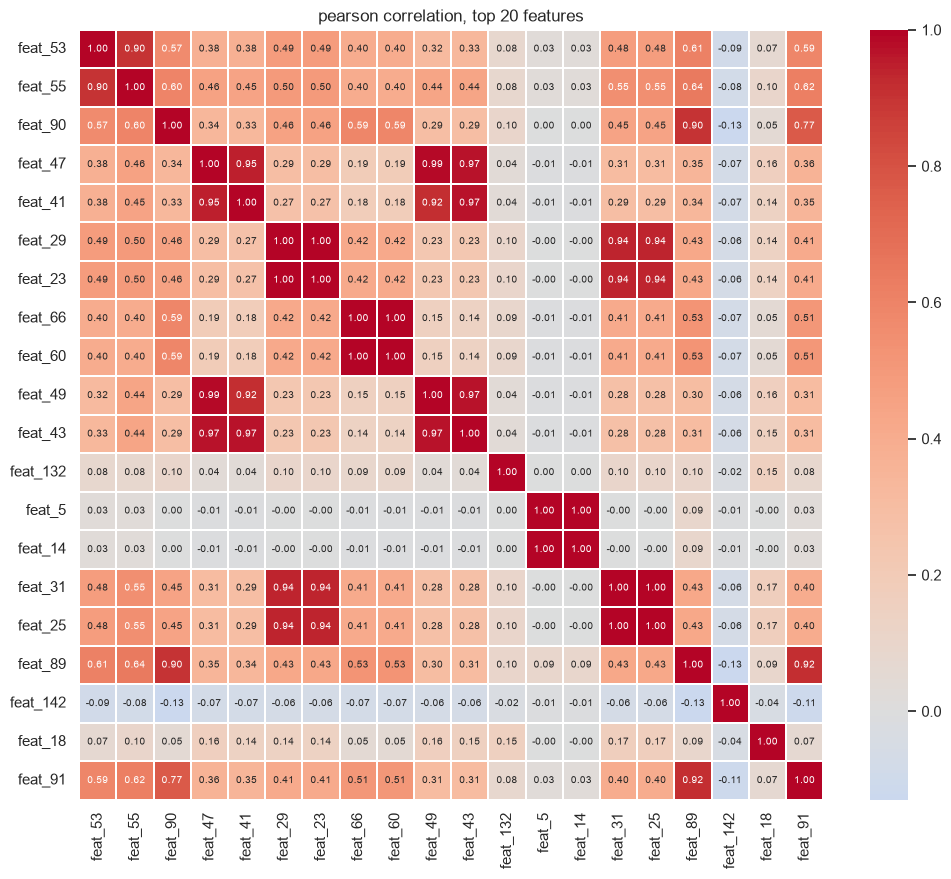

feature pairs with |corr| > 0.95 --> 91


In [8]:
corr_feats = top_features[:20]
corr_df = labelled_df[corr_feats].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df.round(2), cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.05, ax=ax)
ax.set_title('pearson correlation, top 20 features')
plt.savefig(os.path.join(OUT_DIR, 'eda_corr_heatmap.png'), bbox_inches='tight')
plt.show()

# count how many feature pairs are almost duplicates across all raw features
full_corr = labelled_df[raw_features].corr().abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
n_dup_pairs = int((upper > 0.95).sum().sum())
print('feature pairs with |corr| > 0.95 -->', n_dup_pairs)

### 2.6 Hypothesis tests and outliers

A two-sample t-test (Welch) checks whether the mean of each top feature differs between the two classes.
The z-score rule (|z| > 3) counts how many rows would be flagged as outliers per feature.

In [9]:
test_rows = []
for f in top_features[:10]:
    a = labelled_df.loc[labelled_df[output_feature] == 1, f]
    b = labelled_df.loc[labelled_df[output_feature] == 0, f]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    z = (labelled_df[f] - labelled_df[f].mean()) / labelled_df[f].std()
    test_rows.append((f, a.mean(), b.mean(), t, p, int((z.abs() > 3).sum())))
ttest_df = pd.DataFrame(test_rows, columns=['feature', 'mean_illicit', 'mean_licit', 't_stat', 'p_value', 'n_outliers_z3'])
ttest_df.round(4).to_csv(os.path.join(OUT_DIR, 'ttest_outliers.csv'), index=False)
ttest_df.round(4)

,feature,mean_illicit,mean_licit,t_stat,p_value,n_outliers_z3
0,feat_53,-0.2726,1.1931,-115.3967,0.0,1
1,feat_55,-0.2399,0.9958,-93.2044,0.0,14
2,feat_90,-0.5181,0.6890,-101.5678,0.0,3
3,feat_47,-0.1126,0.3976,-45.9958,0.0,539
4,feat_41,-0.1177,0.4074,-46.3997,0.0,515
5,feat_29,-0.1480,0.6678,-55.3032,0.0,524
6,feat_23,-0.1480,0.6678,-55.3044,0.0,524
7,feat_66,-0.1622,0.8204,-65.4939,0.0,554
8,feat_60,-0.1622,0.8204,-65.4961,0.0,554
9,feat_49,-0.1035,0.3469,-40.7414,0.0,1364


### 2.7 Graph structure

Each row is a transaction and each edge is a payment flow between two transactions.
Degrees are computed on the full edge list (including endpoints that are not in train or test, their flow still counts).

edges with both endpoints in the data --> 175918 of 234355
share of those edges inside one time step --> 1.000
edges that cross from train steps to test steps --> 0


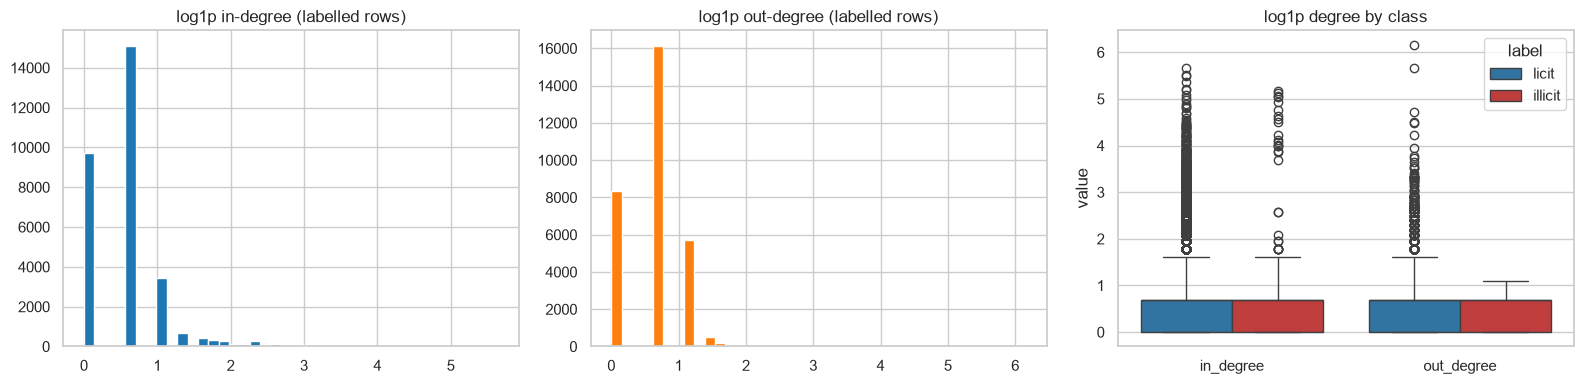

in_degree               out_degree              
           mean median    max       mean median    max
label                                                 
0          1.83    1.0  284.0       1.15    1.0  472.0
1          1.25    1.0  173.0       0.75    1.0    2.0

In [10]:
out_deg = edges_df.txId1.value_counts()
in_deg = edges_df.txId2.value_counts()

node_ts = pd.concat([train_df[['txId', 'time_step']], test_df[['txId', 'time_step']]]).set_index('txId')['time_step']
e_ts = edges_df.assign(t1=edges_df.txId1.map(node_ts), t2=edges_df.txId2.map(node_ts)).dropna()
print('edges with both endpoints in the data --> {} of {}'.format(len(e_ts), len(edges_df)))
print('share of those edges inside one time step --> {:.3f}'.format((e_ts.t1 == e_ts.t2).mean()))
print('edges that cross from train steps to test steps -->', int(((e_ts.t1 <= 35) & (e_ts.t2 >= 36)).sum()))

deg_df = labelled_df[['txId', output_feature]].copy()
deg_df['in_degree'] = deg_df.txId.map(in_deg).fillna(0)
deg_df['out_degree'] = deg_df.txId.map(out_deg).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(np.log1p(deg_df.in_degree), bins=40, color='tab:blue')
axes[0].set_title('log1p in-degree (labelled rows)')
axes[1].hist(np.log1p(deg_df.out_degree), bins=40, color='tab:orange')
axes[1].set_title('log1p out-degree (labelled rows)')
melt = deg_df.melt(id_vars=output_feature, value_vars=['in_degree', 'out_degree'])
melt['value'] = np.log1p(melt['value'])
sns.boxplot(data=melt, x='variable', y='value', hue=melt[output_feature].map({0: 'licit', 1: 'illicit'}), palette=['tab:blue', 'tab:red'], ax=axes[2])
axes[2].set_title('log1p degree by class')
axes[2].set_xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_degrees.png'), bbox_inches='tight')
plt.show()
deg_df.groupby(output_feature)[['in_degree', 'out_degree']].agg(['mean', 'median', 'max']).round(2)

Edges never cross from the training period into the test period, so neighbour labels are of no use for the test rows.
Graph features therefore have to be label-free (degrees and aggregates of neighbour features).

### 2.8 Train versus test drift

The test rows come from later time steps. Comparing the distribution of the strongest features between
train and test shows whether the model will be scored on data that looks like what it was trained on.

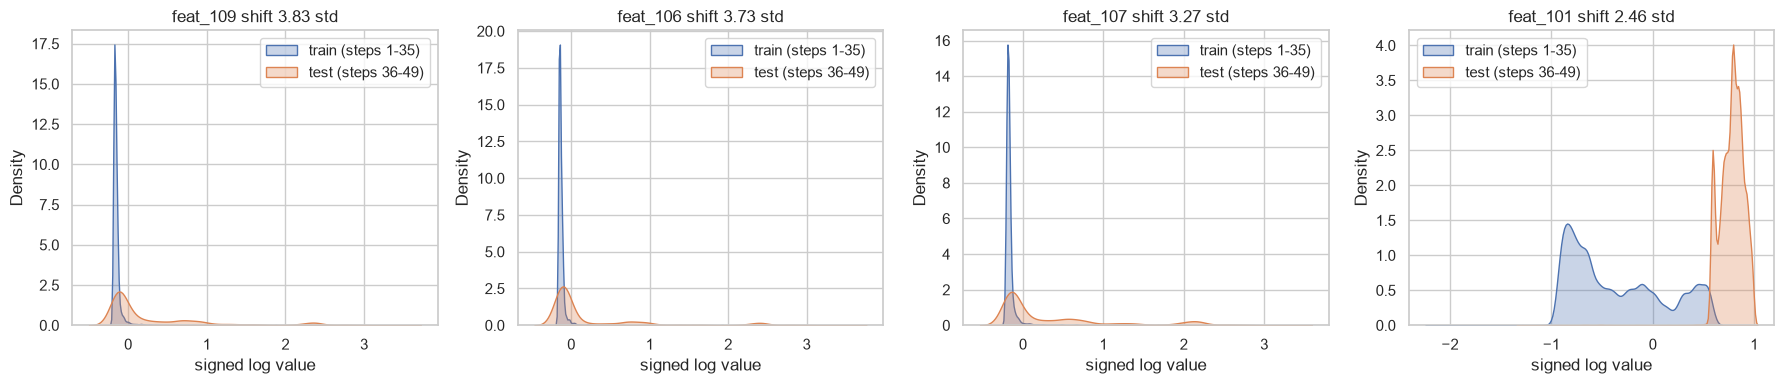

features whose mean moves by more than 0.25 train std --> 44


,feature,train_mean,test_mean,train_std,test_std,mean_shift
0,feat_109,-0.136,1.005,0.298,2.795,3.829
1,feat_106,-0.122,0.887,0.271,2.881,3.725
2,feat_107,-0.141,1.124,0.386,2.671,3.274
3,feat_101,-0.528,1.186,0.697,0.252,2.461
4,feat_103,-0.527,1.184,0.698,0.253,2.450
5,feat_100,-0.521,1.172,0.711,0.255,2.382
6,feat_136,-0.487,1.090,0.742,0.566,2.124
7,feat_139,-0.473,1.083,0.768,0.586,2.026


In [11]:
drift_rows = []
for f in raw_features:
    drift_rows.append((f, train_df[f].mean(), test_df[f].mean(), train_df[f].std(), test_df[f].std()))
drift_df = pd.DataFrame(drift_rows, columns=['feature', 'train_mean', 'test_mean', 'train_std', 'test_std'])
drift_df['mean_shift'] = (drift_df.test_mean - drift_df.train_mean).abs() / drift_df.train_std
drift_df = drift_df.sort_values('mean_shift', ascending=False).reset_index(drop=True)
drift_df.round(3).to_csv(os.path.join(OUT_DIR, 'drift_table.csv'), index=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, drift_df.feature.head(4)):
    sns.kdeplot(signed_log(train_df[f]), ax=ax, label='train (steps 1-35)', fill=True, alpha=0.3)
    sns.kdeplot(signed_log(test_df[f]), ax=ax, label='test (steps 36-49)', fill=True, alpha=0.3)
    ax.set_title('{} shift {:.2f} std'.format(f, drift_df.set_index('feature').loc[f, 'mean_shift']))
    ax.set_xlabel('signed log value')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_drift.png'), bbox_inches='tight')
plt.show()
print('features whose mean moves by more than 0.25 train std -->', int((drift_df.mean_shift > 0.25).sum()))
drift_df.head(8).round(3)

Some of the shifted features are not shifting because of a sudden change, they simply trend with time.
If the mean of a feature per time step is almost a straight line in the time step, the feature is behaving like
a clock. Such a feature would take values in the test period that never occur in training, exactly the reason
`time_step` is excluded as an input, so these features are dropped from every model.

time-proxy features (|corr| > 0.98) --> ['feat_101', 'feat_103', 'feat_136', 'feat_139', 'feat_100', 'feat_137']


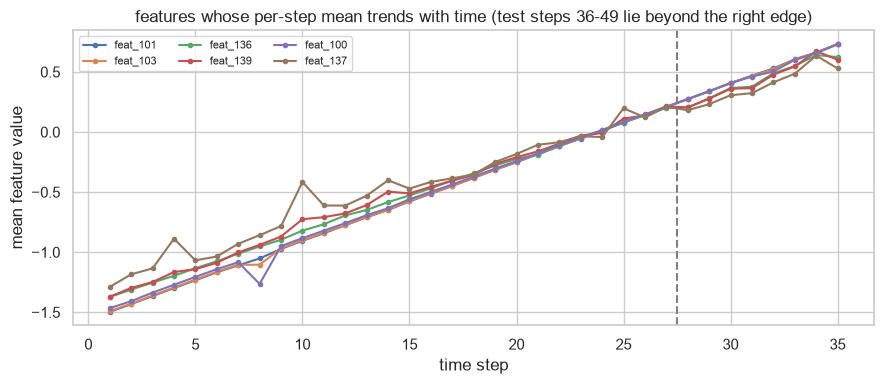

,trend_corr,mean_shift
feat_101,1.000,2.461
feat_103,1.000,2.450
feat_136,1.000,2.124
feat_139,0.998,2.026
feat_100,0.998,2.382
feat_137,0.989,1.645
feat_151,0.938,1.122
feat_148,0.938,1.021
feat_3,0.935,1.205
feat_112,0.927,1.137


In [12]:
# per-step mean of every feature, then how linearly that mean follows the time step
step_means = train_df.groupby('time_step')[raw_features].mean()
trend_corr = step_means.apply(lambda s: np.corrcoef(s.values, step_means.index.values)[0, 1]).abs()
trend_df = pd.DataFrame({'trend_corr': trend_corr}).join(drift_df.set_index('feature')[['mean_shift']]).sort_values('trend_corr', ascending=False)
trend_df.round(3).to_csv(os.path.join(OUT_DIR, 'time_trend.csv'))

TREND_THRESHOLD = 0.98
time_proxy_features = trend_df.index[trend_df.trend_corr > TREND_THRESHOLD].tolist()
print('time-proxy features (|corr| > {}) -->'.format(TREND_THRESHOLD), time_proxy_features)

fig, ax = plt.subplots(figsize=(9, 4))
for f in time_proxy_features:
    ax.plot(step_means.index, step_means[f], marker='.', label=f)
ax.axvline(VALID_START - 0.5, ls='--', color='grey')
ax.set_xlabel('time step')
ax.set_ylabel('mean feature value')
ax.set_title('features whose per-step mean trends with time (test steps 36-49 lie beyond the right edge)')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eda_time_proxies.png'), bbox_inches='tight')
plt.show()
trend_df.head(10).round(3)

## 3. Feature engineering

### 3.1 Graph features from the edge list

For every node in train and test:

* `in_degree`, `out_degree`, `total_degree` and their log1p versions, counted on the full edge list
* `in_nb_known`, `out_nb_known` --> how many of those neighbours have feature rows in train or test
* mean and max of the top 30 features over the in-neighbours and over the out-neighbours

Unlabelled training rows take part here as neighbours, which is the only way they are used.

In [13]:
kept_features = [f for f in raw_features if f not in time_proxy_features]
nb_features = [f for f in uni_auc_df.feature if f in kept_features][:30]  # top 30 by univariate auc on the training split, time proxies excluded
print('raw features kept -->', len(kept_features), '| neighbour features -->', len(nb_features))

def build_graph_features(node_df, edges, nb_feats):
    # node_df must have txId plus the neighbour features for every node that can be a neighbour
    out = pd.DataFrame({'txId': node_df.txId.values})
    out['in_degree'] = out.txId.map(edges.txId2.value_counts()).fillna(0).astype(int)
    out['out_degree'] = out.txId.map(edges.txId1.value_counts()).fillna(0).astype(int)
    out['total_degree'] = out.in_degree + out.out_degree
    for c in ['in_degree', 'out_degree', 'total_degree']:
        out['log_' + c] = np.log1p(out[c])

    feats = node_df[['txId'] + nb_feats]
    # in-neighbours of txId2 are the txId1 side of each edge
    in_df = edges.merge(feats, left_on='txId1', right_on='txId', how='inner').drop(columns=['txId', 'txId1'])
    in_agg = in_df.groupby('txId2')[nb_feats].agg(['mean', 'max'])
    in_agg.columns = ['in_{}_{}'.format(stat, f) for f, stat in in_agg.columns]
    in_agg['in_nb_known'] = in_df.groupby('txId2').size()
    # out-neighbours of txId1 are the txId2 side
    out_df = edges.merge(feats, left_on='txId2', right_on='txId', how='inner').drop(columns=['txId', 'txId2'])
    out_agg = out_df.groupby('txId1')[nb_feats].agg(['mean', 'max'])
    out_agg.columns = ['out_{}_{}'.format(stat, f) for f, stat in out_agg.columns]
    out_agg['out_nb_known'] = out_df.groupby('txId1').size()

    out = out.merge(in_agg, left_on='txId', right_index=True, how='left')
    out = out.merge(out_agg, left_on='txId', right_index=True, how='left')
    # nodes whose neighbours are all outside the data get zeros, the *_nb_known column records that
    return out.fillna(0)

t0 = time.time()
all_nodes_df = pd.concat([train_df[['txId'] + raw_features], test_df[['txId'] + raw_features]], ignore_index=True)
graph_df = build_graph_features(all_nodes_df, edges_df, nb_features)
graph_features = [c for c in graph_df.columns if c != 'txId']
print('graph features -->', len(graph_features), '| built in {:.1f}s'.format(time.time() - t0))

labelled_df = labelled_df.merge(graph_df, on='txId', how='left')
test_df = test_df.merge(graph_df, on='txId', how='left')
graph_df[['in_degree', 'out_degree', 'in_nb_known', 'out_nb_known']].describe().round(2)

raw features kept --> 159 | neighbour features --> 30


graph features --> 128 | built in 0.9s


,in_degree,out_degree,in_nb_known,out_nb_known
count,157101.00,157101.00,157101.00,157101.00
mean,1.24,1.16,1.12,1.12
std,4.34,1.94,3.51,1.91
min,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,1.00
50%,1.00,1.00,1.00,1.00
75%,1.00,1.00,1.00,1.00
max,284.00,472.00,284.00,472.00


### 3.2 Feature sets per model family

* trees (random forest, LightGBM) --> all kept raw features plus all graph features, untransformed
* linear and neural (logistic regression, MLP) --> same columns but with near-duplicate features removed,
  a signed log transform to tame the tails, then standardised with a scaler fitted on the training rows only

`time_step` and the time-proxy features found in section 2.8 are never used as inputs because the test steps lie outside the training range.

In [14]:
tree_features = kept_features + graph_features

def drop_near_duplicates(df, features, threshold=0.95):
    # greedy --> walk through the features in order and drop any that is almost a copy of one kept earlier
    corr = df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return [f for f in features if f not in to_drop], to_drop

linear_features, dropped_features = drop_near_duplicates(split_train_df.merge(graph_df, on='txId', how='left'), tree_features)
print('tree features -->', len(tree_features), '| linear features -->', len(linear_features), '| dropped -->', len(dropped_features))

def scale_data(train, others, features):
    # fit on train only, apply the same transform everywhere
    scaler = StandardScaler()
    train_x = scaler.fit_transform(signed_log(train[features].values))
    others_x = [scaler.transform(signed_log(o[features].values)) for o in others]
    return train_x, others_x, scaler

tree features --> 287 | linear features --> 187 | dropped --> 100


## 4. Validation split

Train on time steps 1 to 27 and validate on 28 to 35. This keeps the same forward-in-time relationship
that exists between train and test. Model selection and all tuning use validation AUC.

In [15]:
def get_time_split(df, valid_start):
    train = df[df.time_step < valid_start].reset_index(drop=True)
    valid = df[df.time_step >= valid_start].reset_index(drop=True)
    return train, valid

tr_df, va_df = get_time_split(labelled_df, VALID_START)
y_tr = tr_df[output_feature].values
y_va = va_df[output_feature].values
print('train rows --> {} (illicit {:.3f}) | valid rows --> {} (illicit {:.3f})'.format(len(tr_df), y_tr.mean(), len(va_df), y_va.mean()))

X_tr_tree = tr_df[tree_features].values
X_va_tree = va_df[tree_features].values
X_tr_lin, (X_va_lin,), _ = scale_data(tr_df, [va_df], linear_features)

train rows --> 24923 (illicit 0.099) | valid rows --> 6312 (illicit 0.188)


## 5. Models

Every model is scored with the same helper so the comparison is fair.
The decision threshold for the confusion matrix is the one that maximises F1 on validation,
the AUC itself does not depend on any threshold.

In [16]:
valid_preds = {}   # model name --> validation probabilities
results = {}       # model name --> dict of metrics

def performance_assessment(y_true, y_prob, rounded=True):
    auc = metrics.roc_auc_score(y_true, y_prob)
    ap = metrics.average_precision_score(y_true, y_prob)
    return {'auc': round(auc, 4) if rounded else auc, 'ap': round(ap, 4) if rounded else ap}

def best_f1_threshold(y_true, y_prob):
    prec, rec, thr = metrics.precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)
    return thr[int(np.argmax(f1))], f1.max()

def auc_per_step(df, y_prob):
    rows = []
    for ts, idx in df.groupby('time_step').indices.items():
        y = df[output_feature].values[idx]
        if y.min() != y.max():
            rows.append((ts, metrics.roc_auc_score(y, y_prob[idx]), len(idx)))
    return pd.DataFrame(rows, columns=['time_step', 'auc', 'n'])

def report_model(name, y_true, y_prob, show_matrix=True):
    perf = performance_assessment(y_true, y_prob)
    thr, f1 = best_f1_threshold(y_true, y_prob)
    y_pred = (y_prob >= thr).astype(int)
    perf.update({'f1_at_thr': round(f1, 4), 'threshold': round(float(thr), 4)})
    results[name] = perf
    valid_preds[name] = y_prob
    print('{} --> auc {:.4f} | ap {:.4f} | f1 {:.4f} at threshold {:.3f}'.format(name, perf['auc'], perf['ap'], f1, thr))
    if show_matrix:
        cm = metrics.confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(4, 3.2))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['licit', 'illicit'], yticklabels=['licit', 'illicit'], ax=ax)
        ax.set_xlabel('predicted')
        ax.set_ylabel('actual')
        ax.set_title('{} confusion matrix'.format(name))
        plt.show()
        print(metrics.classification_report(y_true, y_pred, target_names=['licit', 'illicit'], zero_division=0))
    return perf

### 5.1 Logistic regression (baseline from the lectures)

Grid --> C in {0.01, 0.1, 1}, with and without balanced class weights.

In [17]:
lr_rows = []
lr_models = {}
for C in [0.01, 0.1, 1.0]:
    for cw in [None, 'balanced']:
        model = LogisticRegression(C=C, class_weight=cw, max_iter=2000, random_state=SEED)
        model.fit(X_tr_lin, y_tr)
        prob = model.predict_proba(X_va_lin)[:, 1]
        perf = performance_assessment(y_va, prob)
        lr_rows.append({'C': C, 'class_weight': cw, **perf})
        lr_models[(C, cw)] = (model, prob)
lr_grid_df = pd.DataFrame(lr_rows).sort_values('auc', ascending=False).reset_index(drop=True)
lr_grid_df

,C,class_weight,auc,ap
0,1.00,NaN,0.9624,0.8155
1,0.10,NaN,0.9528,0.8110
2,1.00,balanced,0.9527,0.7312
3,0.10,balanced,0.9403,0.7054
4,0.01,NaN,0.9297,0.7750
5,0.01,balanced,0.9287,0.7141


best logistic regression --> (np.float64(1.0), None)
logistic_regression --> auc 0.9624 | ap 0.8155 | f1 0.8367 at threshold 0.726


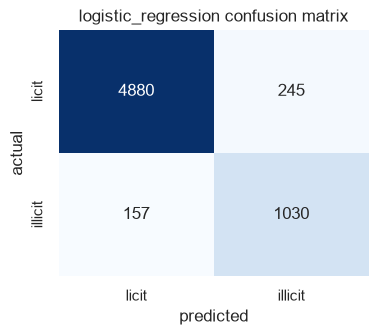

              precision    recall  f1-score   support

       licit       0.97      0.95      0.96      5125
     illicit       0.81      0.87      0.84      1187

    accuracy                           0.94      6312
   macro avg       0.89      0.91      0.90      6312
weighted avg       0.94      0.94      0.94      6312



{'auc': 0.9624,
 'ap': 0.8155,
 'f1_at_thr': np.float64(0.8367),
 'threshold': 0.7262}

In [18]:
best_lr_key = (lr_grid_df.loc[0, 'C'], lr_grid_df.loc[0, 'class_weight'])
best_lr_key = (best_lr_key[0], None if pd.isna(best_lr_key[1]) else best_lr_key[1])
lr_model, lr_prob = lr_models[best_lr_key]
print('best logistic regression -->', best_lr_key)
report_model('logistic_regression', y_va, lr_prob)

### 5.2 Random forest

Grid --> max_depth in {None, 12, 20} and min_samples_leaf in {1, 5}, 300 trees each.

In [19]:
rf_rows = []
rf_models = {}
for depth in [None, 12, 20]:
    for leaf in [1, 5]:
        t0 = time.time()
        model = RandomForestClassifier(n_estimators=300, max_depth=depth, min_samples_leaf=leaf, n_jobs=-1, random_state=SEED)
        model.fit(X_tr_tree, y_tr)
        prob = model.predict_proba(X_va_tree)[:, 1]
        perf = performance_assessment(y_va, prob)
        rf_rows.append({'max_depth': depth, 'min_samples_leaf': leaf, **perf, 'seconds': round(time.time() - t0, 1)})
        rf_models[(depth, leaf)] = (model, prob)
rf_grid_df = pd.DataFrame(rf_rows).sort_values('auc', ascending=False).reset_index(drop=True)
rf_grid_df

,max_depth,min_samples_leaf,auc,ap,seconds
0,20.0,1,0.9962,0.9900,7.8
1,NaN,1,0.9959,0.9895,8.1
2,NaN,5,0.9957,0.9893,7.4
3,12.0,1,0.9957,0.9894,7.6
4,20.0,5,0.9957,0.9894,7.2
5,12.0,5,0.9955,0.9889,7.3


best random forest --> (20, 1)
random_forest --> auc 0.9962 | ap 0.9900 | f1 0.9692 at threshold 0.381


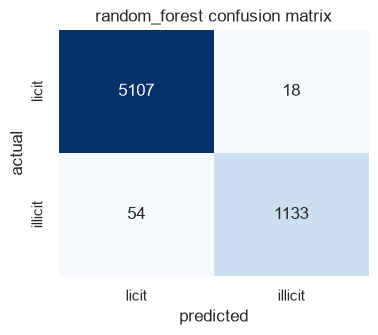

              precision    recall  f1-score   support

       licit       0.99      1.00      0.99      5125
     illicit       0.98      0.95      0.97      1187

    accuracy                           0.99      6312
   macro avg       0.99      0.98      0.98      6312
weighted avg       0.99      0.99      0.99      6312



{'auc': 0.9962,
 'ap': 0.99,
 'f1_at_thr': np.float64(0.9692),
 'threshold': 0.3809}

In [20]:
best_rf_key = (rf_grid_df.loc[0, 'max_depth'], int(rf_grid_df.loc[0, 'min_samples_leaf']))
best_rf_key = (None if pd.isna(best_rf_key[0]) else int(best_rf_key[0]), best_rf_key[1])
rf_model, rf_prob = rf_models[best_rf_key]
print('best random forest -->', best_rf_key)
report_model('random_forest', y_va, rf_prob)

### 5.3 LightGBM

Grid --> num_leaves in {31, 63, 127}, learning_rate in {0.03, 0.1}, scale_pos_weight either 1 or the licit/illicit ratio.
Each run uses early stopping on validation AUC so the number of trees is picked automatically.

In [21]:
pos_ratio = (y_tr == 0).sum() / (y_tr == 1).sum()
lgb_rows = []
lgb_models = {}
for leaves in [31, 63, 127]:
    for lr_ in [0.03, 0.1]:
        for spw in [1.0, round(pos_ratio, 2)]:
            t0 = time.time()
            model = lgb.LGBMClassifier(n_estimators=3000, learning_rate=lr_, num_leaves=leaves, scale_pos_weight=spw,
                                       subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                       random_state=SEED, verbose=-1, n_jobs=-1)
            model.fit(X_tr_tree, y_tr, eval_set=[(X_va_tree, y_va)], eval_metric='auc',
                      callbacks=[lgb.early_stopping(100, verbose=False)])
            prob = model.predict_proba(X_va_tree)[:, 1]
            perf = performance_assessment(y_va, prob)
            lgb_rows.append({'num_leaves': leaves, 'learning_rate': lr_, 'scale_pos_weight': spw, 'best_iter': model.best_iteration_, **perf, 'seconds': round(time.time() - t0, 1)})
            lgb_models[(leaves, lr_, spw)] = (model, prob)
lgb_grid_df = pd.DataFrame(lgb_rows).sort_values('auc', ascending=False).reset_index(drop=True)
lgb_grid_df

,num_leaves,learning_rate,scale_pos_weight,best_iter,auc,ap,seconds
0,127,0.10,1.00,101,0.9976,0.9918,11.0
1,31,0.03,9.14,436,0.9973,0.9896,15.1
2,63,0.03,1.00,259,0.9973,0.9902,15.5
3,63,0.03,9.14,313,0.9973,0.9898,19.3
4,127,0.03,9.14,298,0.9973,0.9907,25.9
5,31,0.03,1.00,333,0.9972,0.9903,11.1
6,63,0.10,1.00,76,0.9972,0.9904,7.9
7,31,0.10,1.00,80,0.9971,0.9903,5.1
8,127,0.03,1.00,270,0.9971,0.9904,24.2
9,127,0.10,9.14,97,0.9971,0.9901,12.2


best lightgbm --> (127, 0.1, 1.0) | trees --> 101
lightgbm --> auc 0.9976 | ap 0.9918 | f1 0.9646 at threshold 0.194


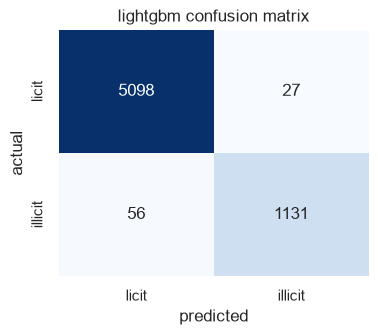

              precision    recall  f1-score   support

       licit       0.99      0.99      0.99      5125
     illicit       0.98      0.95      0.96      1187

    accuracy                           0.99      6312
   macro avg       0.98      0.97      0.98      6312
weighted avg       0.99      0.99      0.99      6312



{'auc': 0.9976,
 'ap': 0.9918,
 'f1_at_thr': np.float64(0.9646),
 'threshold': 0.194}

In [22]:
best_lgb_key = (int(lgb_grid_df.loc[0, 'num_leaves']), float(lgb_grid_df.loc[0, 'learning_rate']), float(lgb_grid_df.loc[0, 'scale_pos_weight']))
lgb_model, lgb_prob = lgb_models[best_lgb_key]
print('best lightgbm -->', best_lgb_key, '| trees -->', lgb_model.best_iteration_)
report_model('lightgbm', y_va, lgb_prob)

### 5.4 Multi-layer perceptron (PyTorch)

Two hidden layers (256, 128) with ReLU and dropout 0.3, Adam with learning rate 1e-3, batch size 256,
BCEWithLogits loss and early stopping on validation AUC with patience 5, following the training loop from lecture 04.

epoch   5 | train loss 0.0516 | valid auc 0.9801


epoch  10 | train loss 0.0338 | valid auc 0.9773


early stopping at epoch 13 --> best epoch 8 with auc 0.9825


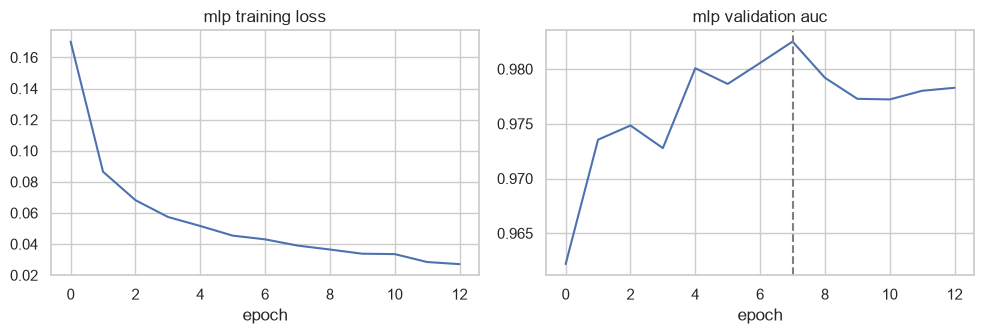

mlp --> auc 0.9825 | ap 0.9341 | f1 0.8891 at threshold 0.664


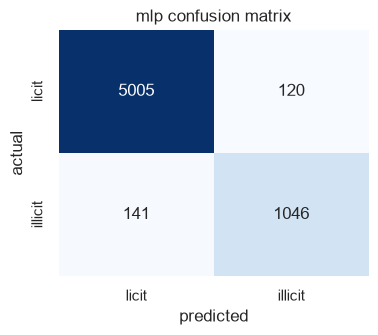

              precision    recall  f1-score   support

       licit       0.97      0.98      0.97      5125
     illicit       0.90      0.88      0.89      1187

    accuracy                           0.96      6312
   macro avg       0.93      0.93      0.93      6312
weighted avg       0.96      0.96      0.96      6312



{'auc': 0.9825,
 'ap': 0.9341,
 'f1_at_thr': np.float64(0.8891),
 'threshold': 0.6635}

In [23]:
class FraudMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=(256, 128), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def make_loader(X, y=None, batch_size=256, shuffle=False):
    xt = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
    if y is None:
        return DataLoader(TensorDataset(xt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(xt, torch.from_numpy(np.asarray(y, dtype=np.float32))), batch_size=batch_size, shuffle=shuffle)

def predict_mlp(model, X):
    model.eval()
    out = []
    with torch.no_grad():
        for (xb,) in make_loader(X, batch_size=2048):
            out.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    return np.concatenate(out)

def train_mlp(X_train, y_train, X_valid=None, y_valid=None, max_epochs=100, patience=5, lr=1e-3, verbose=True, seed=SEED):
    set_seed(seed)
    model = FraudMLP(X_train.shape[1]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train, shuffle=True)
    history = {'train_loss': [], 'valid_auc': []}
    best_auc, best_epoch, best_state, wait = -1, 0, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        history['train_loss'].append(np.mean(losses))
        if X_valid is None:
            continue
        auc = metrics.roc_auc_score(y_valid, predict_mlp(model, X_valid))
        history['valid_auc'].append(auc)
        if auc > best_auc:
            best_auc, best_epoch, wait = auc, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if verbose and epoch % 5 == 0:
            print('epoch {:3d} | train loss {:.4f} | valid auc {:.4f}'.format(epoch, history['train_loss'][-1], auc))
        if wait >= patience:
            if verbose:
                print('early stopping at epoch {} --> best epoch {} with auc {:.4f}'.format(epoch, best_epoch, best_auc))
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_epoch

mlp_model, mlp_history, mlp_best_epoch = train_mlp(X_tr_lin, y_tr, X_va_lin, y_va)
mlp_prob = predict_mlp(mlp_model, X_va_lin)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mlp_history['train_loss'])
axes[0].set_title('mlp training loss')
axes[0].set_xlabel('epoch')
axes[1].plot(mlp_history['valid_auc'])
axes[1].axvline(mlp_best_epoch - 1, ls='--', color='grey')
axes[1].set_title('mlp validation auc')
axes[1].set_xlabel('epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mlp_training_curves.png'), bbox_inches='tight')
plt.show()
report_model('mlp', y_va, mlp_prob)

### 5.5 Model comparison, ROC curves and per-step AUC

                        auc      ap  f1_at_thr  threshold
lightgbm             0.9976  0.9918     0.9646     0.1940
random_forest        0.9962  0.9900     0.9692     0.3809
mlp                  0.9825  0.9341     0.8891     0.6635
logistic_regression  0.9624  0.8155     0.8367     0.7262


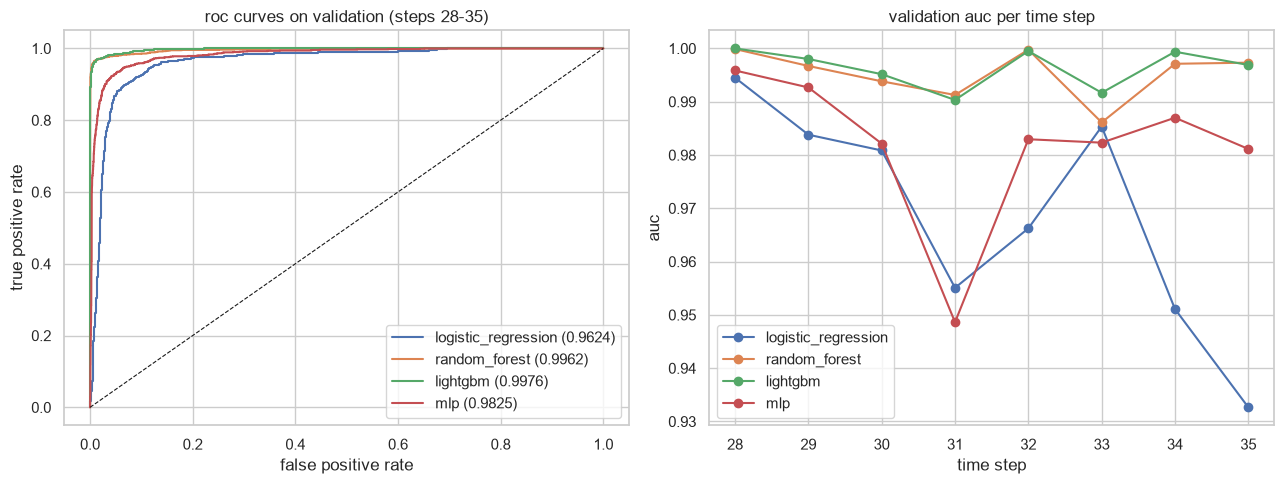

,logistic_regression,random_forest,lightgbm,mlp
time_step,,,,
28,0.995,1.000,1.000,0.996
29,0.984,0.997,0.998,0.993
30,0.981,0.994,0.995,0.982
31,0.955,0.991,0.990,0.949
32,0.966,1.000,1.000,0.983
33,0.985,0.986,0.992,0.982
34,0.951,0.997,0.999,0.987
35,0.933,0.997,0.997,0.981


In [24]:
results_df = pd.DataFrame(results).T.sort_values('auc', ascending=False)
results_df.to_csv(os.path.join(OUT_DIR, 'validation_results.csv'))
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, prob in valid_preds.items():
    fpr, tpr, _ = metrics.roc_curve(y_va, prob)
    axes[0].plot(fpr, tpr, label='{} ({:.4f})'.format(name, results[name]['auc']))
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].set_title('roc curves on validation (steps 28-35)')
axes[0].legend()

step_auc = {}
for name, prob in valid_preds.items():
    s = auc_per_step(va_df, prob).set_index('time_step')['auc']
    step_auc[name] = s
    axes[1].plot(s.index, s.values, marker='o', label=name)
axes[1].set_xlabel('time step')
axes[1].set_ylabel('auc')
axes[1].set_title('validation auc per time step')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'roc_and_step_auc.png'), bbox_inches='tight')
plt.show()
pd.DataFrame(step_auc).round(3)

### 5.6 Feature importance and the value of the graph features

Importance is read from LightGBM (gain) and the random forest (impurity decrease).
The ablation retrains the best LightGBM configuration on three feature sets: all raw features, raw features without
the time proxies, and the final set with graph features, so the effect of each decision is visible on validation.

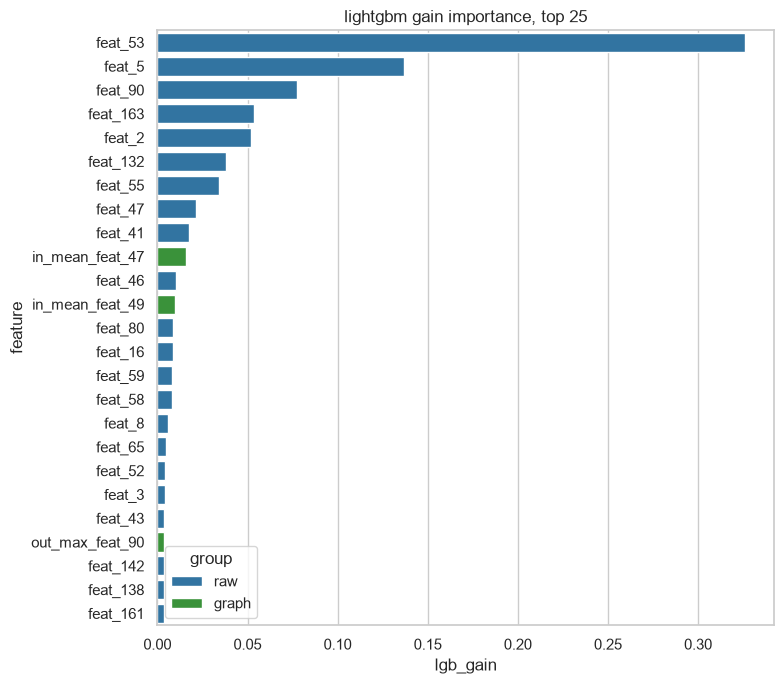

share of lightgbm gain from graph features --> 0.070


,lgb_gain,rf_impurity
group,,
graph,0.07,0.157
raw,0.93,0.843


In [25]:
imp_df = pd.DataFrame({
    'feature': tree_features,
    'lgb_gain': lgb_model.booster_.feature_importance(importance_type='gain'),
    'rf_impurity': rf_model.feature_importances_})
imp_df['lgb_gain'] = imp_df.lgb_gain / imp_df.lgb_gain.sum()
imp_df['group'] = np.where(imp_df.feature.str.startswith('feat_'), 'raw', 'graph')
imp_df = imp_df.sort_values('lgb_gain', ascending=False).reset_index(drop=True)
imp_df.to_csv(os.path.join(OUT_DIR, 'feature_importance.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 7))
top_imp = imp_df.head(25)
sns.barplot(data=top_imp, y='feature', x='lgb_gain', hue='group', dodge=False, palette={'raw': 'tab:blue', 'graph': 'tab:green'}, ax=ax)
ax.set_title('lightgbm gain importance, top 25')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_importance.png'), bbox_inches='tight')
plt.show()
print('share of lightgbm gain from graph features --> {:.3f}'.format(imp_df.loc[imp_df.group == 'graph', 'lgb_gain'].sum()))
imp_df.groupby('group')[['lgb_gain', 'rf_impurity']].sum().round(3)

In [26]:
# ablation --> same lightgbm configuration, different feature sets
leaves, lr_, spw = best_lgb_key
def fit_lgb_on(features):
    m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=lr_, num_leaves=leaves, scale_pos_weight=spw,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1, n_jobs=-1)
    m.fit(tr_df[features].values, y_tr, eval_set=[(va_df[features].values, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(100, verbose=False)])
    return m.predict_proba(va_df[features].values)[:, 1]

ablation_rows = []
for name, feats in [('all raw features', raw_features), ('raw without time proxies', kept_features)]:
    ablation_rows.append({'features': name, 'n_features': len(feats), **performance_assessment(y_va, fit_lgb_on(feats))})
ablation_rows.append({'features': 'raw without time proxies + graph', 'n_features': len(tree_features), **performance_assessment(y_va, lgb_prob)})
ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(os.path.join(OUT_DIR, 'ablation.csv'), index=False)
ablation_df

,features,n_features,auc,ap
0,all raw features,165,0.9966,0.9878
1,raw without time proxies,159,0.9969,0.9886
2,raw without time proxies + graph,287,0.9976,0.9918


## 6. Blending

Validation probabilities are converted to ranks and averaged, which makes models with different probability
scales comparable. Every combination of two or more models is scored so the choice of blend is based on evidence.

In [27]:
def rank_average(prob_list):
    ranks = [stats.rankdata(p) / len(p) for p in prob_list]
    return np.mean(ranks, axis=0)

blend_rows = []
model_names = list(valid_preds.keys())
for k in range(2, len(model_names) + 1):
    for combo in itertools.combinations(model_names, k):
        prob = rank_average([valid_preds[m] for m in combo])
        blend_rows.append({'blend': ' + '.join(combo), 'n_models': k, **performance_assessment(y_va, prob)})
blend_df = pd.DataFrame(blend_rows).sort_values('auc', ascending=False).reset_index(drop=True)
blend_df.to_csv(os.path.join(OUT_DIR, 'blend_results.csv'), index=False)
print('best single model --> {} ({:.4f})'.format(results_df.index[0], results_df.auc.iloc[0]))
blend_df

best single model --> lightgbm (0.9976)


,blend,n_models,auc,ap
0,random_forest + lightgbm,2,0.9975,0.9920
1,random_forest + lightgbm + mlp,3,0.9970,0.9900
2,logistic_regression + random_forest + lightgbm,3,0.9954,0.9848
3,lightgbm + mlp,2,0.9952,0.9841
4,random_forest + mlp,2,0.9950,0.9846
5,logistic_regression + random_forest + lightgbm...,4,0.9949,0.9837
6,logistic_regression + lightgbm,2,0.9919,0.9737
7,logistic_regression + lightgbm + mlp,3,0.9917,0.9736
8,logistic_regression + random_forest + mlp,3,0.9916,0.9744
9,logistic_regression + random_forest,2,0.9911,0.9722


## 7. Final models and submission files

Chosen setup --> the selected models are retrained on all labelled rows (steps 1 to 35) with the hyperparameters
picked on validation. LightGBM keeps the number of trees found by early stopping, the MLP keeps the best epoch.
Two candidate files are written: the best single model and the chosen blend.

In [28]:
# final blend --> chosen after reviewing the blend table above, two different tree models tied with the best single model on validation
FINAL_BLEND = ['lightgbm', 'random_forest']
BEST_SINGLE = results_df.index[0]

y_all = labelled_df[output_feature].values
X_all_tree = labelled_df[tree_features].values
X_test_tree = test_df[tree_features].values
X_all_lin, (X_test_lin,), _ = scale_data(labelled_df, [test_df], linear_features)

final_test_preds = {}
needed = set(FINAL_BLEND) | {BEST_SINGLE}

if 'logistic_regression' in needed:
    m = LogisticRegression(C=best_lr_key[0], class_weight=best_lr_key[1], max_iter=2000, random_state=SEED).fit(X_all_lin, y_all)
    final_test_preds['logistic_regression'] = m.predict_proba(X_test_lin)[:, 1]
if 'random_forest' in needed:
    m = RandomForestClassifier(n_estimators=300, max_depth=best_rf_key[0], min_samples_leaf=best_rf_key[1], n_jobs=-1, random_state=SEED).fit(X_all_tree, y_all)
    final_test_preds['random_forest'] = m.predict_proba(X_test_tree)[:, 1]
if 'lightgbm' in needed:
    leaves, lr_, spw = best_lgb_key
    m = lgb.LGBMClassifier(n_estimators=lgb_model.best_iteration_, learning_rate=lr_, num_leaves=leaves, scale_pos_weight=spw,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1, n_jobs=-1).fit(X_all_tree, y_all)
    final_test_preds['lightgbm'] = m.predict_proba(X_test_tree)[:, 1]
if 'mlp' in needed:
    m, _, _ = train_mlp(X_all_lin, y_all, max_epochs=mlp_best_epoch, verbose=False)
    final_test_preds['mlp'] = predict_mlp(m, X_test_lin)

def write_submission(prob, name):
    sub = pd.DataFrame({'index': test_df['index'].values, 'target': prob})
    assert len(sub) == len(sample_sub_df)
    assert (sub['index'].values == sample_sub_df['index'].values).all()
    assert np.isfinite(sub.target).all() and sub.target.between(0, 1).all()
    path = os.path.join(SUB_DIR, name + '.csv')
    sub.to_csv(path, index=False)
    print('wrote', path, '| mean target {:.4f}'.format(sub.target.mean()))
    return path

write_submission(final_test_preds[BEST_SINGLE], 'single_' + BEST_SINGLE)
write_submission(rank_average([final_test_preds[m] for m in FINAL_BLEND]), 'blend_' + '_'.join(FINAL_BLEND))

wrote submissions/single_lightgbm.csv | mean target 0.0425
wrote submissions/blend_lightgbm_random_forest.csv | mean target 0.5000


'submissions/blend_lightgbm_random_forest.csv'

## 8. Drift experiments

The first upload scored 0.9496 on the public leaderboard against 0.9976 on validation, so the test period
drifts more than the validation block did. This section measures the drift with adversarial validation
(a classifier trained to tell training rows from test rows, AUC near 0.5 would mean the two periods look alike)
and then tries settings that should be less sensitive to it. Validation cannot measure the benefit of these
changes, only the leaderboard can, so every variant writes its own submission file and the public score is
recorded in the submission log at the end.

### 8.1 Adversarial validation

train vs test auc --> 0.998


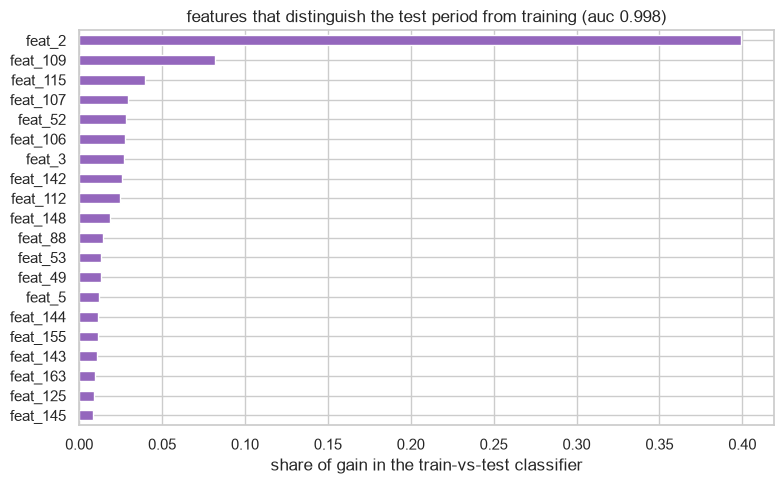

feat_2      0.399
feat_109    0.082
feat_115    0.040
feat_107    0.030
feat_52     0.028
feat_106    0.028
feat_3      0.027
feat_142    0.026
feat_112    0.025
feat_148    0.019
feat_88     0.015
feat_53     0.013
feat_49     0.013
feat_5      0.012
feat_144    0.011
dtype: float64

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

def adversarial_check(features, n_estimators=150):
    # train rows vs test rows --> which features make the two periods look different
    X = np.vstack([train_df[features].values, test_df[features].values])
    y = np.r_[np.zeros(len(train_df)), np.ones(len(test_df))]
    clf = lgb.LGBMClassifier(n_estimators=n_estimators, learning_rate=0.1, num_leaves=31, random_state=SEED, verbose=-1, n_jobs=-1)
    prob = cross_val_predict(clf, X, y, cv=StratifiedKFold(3, shuffle=True, random_state=SEED), method='predict_proba')[:, 1]
    clf.fit(X, y)
    imp = pd.Series(clf.booster_.feature_importance(importance_type='gain'), index=features)
    return metrics.roc_auc_score(y, prob), (imp / imp.sum()).sort_values(ascending=False)

adv_auc, adv_imp = adversarial_check(kept_features)
print('train vs test auc --> {:.3f}'.format(adv_auc))
adv_imp.rename('share_of_gain').to_csv(os.path.join(OUT_DIR, 'adversarial_importance.csv'))

fig, ax = plt.subplots(figsize=(8, 5))
adv_imp.head(20).iloc[::-1].plot(kind='barh', ax=ax, color='tab:purple')
ax.set_xlabel('share of gain in the train-vs-test classifier')
ax.set_title('features that distinguish the test period from training (auc {:.3f})'.format(adv_auc))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'adversarial_importance.png'), bbox_inches='tight')
plt.show()
adv_imp.head(15).round(3)

### 8.2 Removing the most period-specific features in rounds

Five features are removed per round, the adversarial classifier is refitted, and the validation AUC of the
best LightGBM configuration is tracked so that the cost of each removal is visible. Graph aggregates built
from a removed feature are removed together with it.

In [30]:
def without(features, drop):
    # drop the raw features and any neighbour aggregate that was built from them
    return [f for f in features if f not in drop and not any(f.endswith('_' + d) for d in drop)]

def fit_lgb_valid(features, params):
    m = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    m.fit(tr_df[features].values, y_tr, eval_set=[(va_df[features].values, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(100, verbose=False)])
    return m, m.predict_proba(va_df[features].values)[:, 1]

leaves, lr_, spw = best_lgb_key
best_params = dict(learning_rate=lr_, num_leaves=leaves, scale_pos_weight=spw, subsample=0.8, subsample_freq=1, colsample_bytree=0.8)

removal_rows = []
removed_order = []
current_raw = list(kept_features)
imp = adv_imp
for r in range(0, 10):
    if r > 0:
        drop = imp.head(5).index.tolist()
        removed_order += drop
        current_raw = [f for f in current_raw if f not in drop]
        adv_auc_r, imp = adversarial_check(current_raw)
    else:
        adv_auc_r = adv_auc
    feats_r = without(tree_features, removed_order)
    _, prob_r = fit_lgb_valid(feats_r, best_params)
    removal_rows.append({'round': r, 'n_removed': len(removed_order), 'n_features': len(feats_r),
                         'train_vs_test_auc': round(adv_auc_r, 3), **performance_assessment(y_va, prob_r)})
    print(removal_rows[-1])
removal_df = pd.DataFrame(removal_rows)
removal_df.to_csv(os.path.join(OUT_DIR, 'drift_removal.csv'), index=False)
print('removal order -->', removed_order)
removal_df

{'round': 0, 'n_removed': 0, 'n_features': 287, 'train_vs_test_auc': 0.998, 'auc': 0.9976, 'ap': 0.9918}


{'round': 1, 'n_removed': 5, 'n_features': 282, 'train_vs_test_auc': 0.997, 'auc': 0.997, 'ap': 0.99}


{'round': 2, 'n_removed': 10, 'n_features': 269, 'train_vs_test_auc': 0.995, 'auc': 0.9972, 'ap': 0.9906}


{'round': 3, 'n_removed': 15, 'n_features': 264, 'train_vs_test_auc': 0.989, 'auc': 0.9969, 'ap': 0.9899}


{'round': 4, 'n_removed': 20, 'n_features': 251, 'train_vs_test_auc': 0.976, 'auc': 0.9964, 'ap': 0.9883}


...

{'round': 6, 'n_removed': 30, 'n_features': 233, 'train_vs_test_auc': 0.971, 'auc': 0.9963, 'ap': 0.9877}


{'round': 7, 'n_removed': 35, 'n_features': 216, 'train_vs_test_auc': 0.967, 'auc': 0.9966, 'ap': 0.9891}


{'round': 8, 'n_removed': 40, 'n_features': 199, 'train_vs_test_auc': 0.966, 'auc': 0.9966, 'ap': 0.9888}


{'round': 9, 'n_removed': 45, 'n_features': 194, 'train_vs_test_auc': 0.965, 'auc': 0.9966, 'ap': 0.9894}
removal order --> ['feat_2', 'feat_109', 'feat_115', 'feat_107', 'feat_52', 'feat_106', 'feat_3', 'feat_142', 'feat_113', 'feat_53', 'feat_151', 'feat_112', 'feat_145', 'feat_143', 'feat_108', 'feat_148', 'feat_144', 'feat_125', 'feat_55', 'feat_149', 'feat_127', 'feat_155', 'feat_124', 'feat_60', 'feat_88', 'feat_76', 'feat_47', 'feat_157', 'feat_61', 'feat_163', 'feat_82', 'feat_49', 'feat_67', 'feat_156', 'feat_41', 'feat_43', 'feat_58', 'feat_66', 'feat_161', 'feat_162', 'feat_64', 'feat_46', 'feat_95', 'feat_77', 'feat_59']


,round,n_removed,n_features,train_vs_test_auc,auc,ap
0,0,0,287,0.998,0.9976,0.9918
1,1,5,282,0.997,0.9970,0.9900
2,2,10,269,0.995,0.9972,0.9906
3,3,15,264,0.989,0.9969,0.9899
4,4,20,251,0.976,0.9964,0.9883
5,5,25,242,0.971,0.9960,0.9874
6,6,30,233,0.971,0.9963,0.9877
7,7,35,216,0.967,0.9966,0.9891
8,8,40,199,0.966,0.9966,0.9888
9,9,45,194,0.965,0.9966,0.9894


### 8.3 Variants and their submission files

Each variant is fitted on the training split first (to pick the tree count by early stopping and to report
validation AUC) and then refitted on all labelled rows before predicting the test set.

* `drift15` / `drift30` / `drift45` --> best LightGBM settings, minus the first 15 / 30 / 45 period-specific features
* `reg` --> a smoother LightGBM (31 leaves, learning rate 0.03, half the columns per tree, at least 50 rows per leaf)
* `reg_drift15` --> both of the above
* `recent_drift15` --> drift15 trained on time steps 15 to 35 only, closer to the test period
* `rf_drift15` --> the random forest on the drift15 feature set, for blending
* `lgb_recent` --> full feature set, trained on time steps 15 to 35 only, closest era to the test period
* `lgb_weakdrift` --> drop only features that both shift strongly (more than 1 train std) and carry little signal (univariate auc within 0.1 of 0.5), so strong predictors such as feat_53 stay

In [31]:
reg_params = dict(learning_rate=0.03, num_leaves=31, scale_pos_weight=spw, subsample=0.8, subsample_freq=1, colsample_bytree=0.5, min_child_samples=50)

def run_variant(name, features, params=None, min_step=1, model='lgb', weight_col=None):
    tr_v = tr_df[tr_df.time_step >= min_step]
    all_v = labelled_df[labelled_df.time_step >= min_step]
    w_tr = tr_v[weight_col].values if weight_col else None
    w_all = all_v[weight_col].values if weight_col else None
    if model == 'lgb':
        m = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **params)
        m.fit(tr_v[features].values, tr_v[output_feature].values, sample_weight=w_tr, eval_set=[(va_df[features].values, y_va)], eval_metric='auc',
              callbacks=[lgb.early_stopping(100, verbose=False)])
        n_trees = m.best_iteration_
        final = lgb.LGBMClassifier(n_estimators=n_trees, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    else:
        m = RandomForestClassifier(n_estimators=300, max_depth=best_rf_key[0], min_samples_leaf=best_rf_key[1], n_jobs=-1, random_state=SEED)
        m.fit(tr_v[features].values, tr_v[output_feature].values)
        n_trees = 300
        final = RandomForestClassifier(n_estimators=300, max_depth=best_rf_key[0], min_samples_leaf=best_rf_key[1], n_jobs=-1, random_state=SEED)
    variant_valid[name] = m.predict_proba(va_df[features].values)[:, 1]
    perf = performance_assessment(y_va, variant_valid[name])
    final.fit(all_v[features].values, all_v[output_feature].values, sample_weight=w_all)
    prob = final.predict_proba(test_df[features].values)[:, 1]
    variant_preds[name] = prob
    write_submission(prob, name)
    row = {'variant': name, 'n_features': len(features), 'train_rows': len(all_v), 'trees': n_trees, **perf}
    variant_rows.append(row)
    return row

variant_preds = {}
variant_valid = {}  # validation probabilities of each variant, used by the post-processing check in 8.9
variant_rows = []
feats_15 = without(tree_features, removed_order[:15])
feats_30 = without(tree_features, removed_order[:30])
feats_45 = without(tree_features, removed_order[:45])
run_variant('lgb_drift15', feats_15, best_params)
run_variant('lgb_drift30', feats_30, best_params)
run_variant('lgb_drift45', feats_45, best_params)
run_variant('lgb_reg', tree_features, reg_params)
run_variant('lgb_reg_drift15', feats_15, reg_params)
run_variant('lgb_recent_drift15', feats_15, best_params, min_step=15)
run_variant('rf_drift15', feats_15, model='rf')
# weak drift rule --> shifted and uninformative at the same time
shift_lookup = drift_df.set_index('feature')['mean_shift']
auc_lookup = uni_auc_df.set_index('feature')['auc']
weak_drift_features = [f for f in kept_features if shift_lookup[f] > 1 and abs(auc_lookup[f] - 0.5) < 0.1]
print('weak drift features -->', weak_drift_features)
feats_weak = without(tree_features, weak_drift_features)
run_variant('lgb_recent', tree_features, best_params, min_step=15)
run_variant('lgb_weakdrift', feats_weak, best_params)
write_submission(rank_average([variant_preds['lgb_drift15'], variant_preds['rf_drift15']]), 'blend_drift15_lgb_rf')
write_submission(rank_average([variant_preds['lgb_reg_drift15'], variant_preds['rf_drift15']]), 'blend_reg_drift15_lgb_rf')
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df

wrote submissions/lgb_drift15.csv | mean target 0.0475


wrote submissions/lgb_drift30.csv | mean target 0.0464


wrote submissions/lgb_drift45.csv | mean target 0.0461


wrote submissions/lgb_reg.csv | mean target 0.0488


wrote submissions/lgb_reg_drift15.csv | mean target 0.0529


wrote submissions/lgb_recent_drift15.csv | mean target 0.0502


wrote submissions/rf_drift15.csv | mean target 0.0702
weak drift features --> ['feat_2', 'feat_3', 'feat_107', 'feat_109', 'feat_113', 'feat_115', 'feat_143', 'feat_151']


wrote submissions/lgb_recent.csv | mean target 0.0439


wrote submissions/lgb_weakdrift.csv | mean target 0.0455
wrote submissions/blend_drift15_lgb_rf.csv | mean target 0.5000
wrote submissions/blend_reg_drift15_lgb_rf.csv | mean target 0.5000


,variant,n_features,train_rows,trees,auc,ap
0,lgb_drift15,264,31235,61,0.9969,0.9899
1,lgb_drift30,233,31235,56,0.9963,0.9877
2,lgb_drift45,194,31235,57,0.9966,0.9894
3,lgb_reg,287,31235,295,0.9976,0.9912
4,lgb_reg_drift15,264,31235,283,0.9976,0.9916
5,lgb_recent_drift15,264,16339,60,0.9970,0.9901
6,rf_drift15,264,31235,300,0.9957,0.9876
7,lgb_recent,287,16339,63,0.9972,0.9891
8,lgb_weakdrift,279,31235,84,0.9971,0.9902


### 8.4 Per-time-step normalisation

The drift table showed many features changing their level between periods while keeping their shape.
Replacing every value by its percentile rank among the rows of the same time step removes level shifts
completely and keeps each feature's ordering inside the step. Test steps are normalised with their own rows,
which uses only the provided files. All rows of a step (labelled, unlabelled and test) take part so the
ranks are stable, then the labelled and test rows are pulled back out for modelling.

Result --> this one is kept as a negative finding. Within-step percentile ranks cut validation AUC from 0.9976 to
0.915 even though every feature keeps its within-step ordering, because the trees rely on absolute values that mean
the same thing in every step, and the illicit share differs so much between steps that the same percentile means
different things in different steps. A gentler version that only subtracts each step's median keeps 0.995 and is
the form worth trying if level shifts turn out to matter on the leaderboard.

In [32]:
# one frame with every node, raw kept features plus graph features, ranked within its time step
all_rows_df = pd.concat([
    train_df[['txId', 'time_step'] + kept_features].merge(graph_df, on='txId', how='left'),
    test_df[['txId', 'time_step'] + kept_features + graph_features]], ignore_index=True)
ranked_df = all_rows_df[['txId']].copy()
ranked_df[tree_features] = all_rows_df.groupby('time_step')[tree_features].rank(pct=True)

def step_normalised(df):
    # pull the ranked rows for the given frame, in the same row order
    return df[['txId']].merge(ranked_df, on='txId', how='left')[tree_features].values

tr_norm, va_norm, all_norm, test_norm = step_normalised(tr_df), step_normalised(va_df), step_normalised(labelled_df), step_normalised(test_df)
print('nan check -->', int(np.isnan(tr_norm).sum() + np.isnan(test_norm).sum()))

def run_norm_variant(name, params):
    m = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    m.fit(tr_norm, y_tr, eval_set=[(va_norm, y_va)], eval_metric='auc', callbacks=[lgb.early_stopping(100, verbose=False)])
    perf = performance_assessment(y_va, m.predict_proba(va_norm)[:, 1])
    final = lgb.LGBMClassifier(n_estimators=m.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **params).fit(all_norm, y_all)
    prob = final.predict_proba(test_norm)[:, 1]
    variant_preds[name] = prob
    write_submission(prob, name)
    row = {'variant': name, 'n_features': len(tree_features), 'train_rows': len(labelled_df), 'trees': m.best_iteration_, **perf}
    variant_rows.append(row)
    return row

run_norm_variant('lgb_stepnorm', best_params)
run_norm_variant('lgb_reg_stepnorm', reg_params)
write_submission(rank_average([variant_preds['lgb_stepnorm'], variant_preds['lgb_reg']]), 'blend_stepnorm_reg')
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df

/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/2220983293.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ranked_df[tree_features] = all_rows_df.groupby('time_step')[tree_features].rank(pct=True)


nan check --> 0


wrote submissions/lgb_stepnorm.csv | mean target 0.0986


wrote submissions/lgb_reg_stepnorm.csv | mean target 0.0996
wrote submissions/blend_stepnorm_reg.csv | mean target 0.5000


,variant,n_features,train_rows,trees,auc,ap
0,lgb_drift15,264,31235,61,0.9969,0.9899
1,lgb_drift30,233,31235,56,0.9963,0.9877
2,lgb_drift45,194,31235,57,0.9966,0.9894
3,lgb_reg,287,31235,295,0.9976,0.9912
4,lgb_reg_drift15,264,31235,283,0.9976,0.9916
5,lgb_recent_drift15,264,16339,60,0.9970,0.9901
6,rf_drift15,264,31235,300,0.9957,0.9876
7,lgb_recent,287,16339,63,0.9972,0.9891
8,lgb_weakdrift,279,31235,84,0.9971,0.9902
9,lgb_stepnorm,287,31235,13,0.9150,0.8376


### 8.5 Importance weighting and time decay

Two ways to make the training set look more like the test period without dropping anything:

* importance weights --> each training row is weighted by how much it resembles a test row according to the
  adversarial classifier (odds p / (1 - p), softened with a square root and clipped so a few rows cannot dominate)
* time decay --> rows from recent time steps weigh more, with a half-life of 10 steps

The same cell also fits an even smoother LightGBM (15 leaves, learning rate 0.02, 40% of columns per tree, at least 100 rows
per leaf), because the smoother model was the first upload to beat the baseline on the leaderboard.

In [33]:
# out-of-fold adversarial probabilities for every training row --> weights that are not overfitted
X_adv = np.vstack([train_df[kept_features].values, test_df[kept_features].values])
y_adv = np.r_[np.zeros(len(train_df)), np.ones(len(test_df))]
adv_clf = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.1, num_leaves=31, random_state=SEED, verbose=-1, n_jobs=-1)
p_adv = cross_val_predict(adv_clf, X_adv, y_adv, cv=StratifiedKFold(3, shuffle=True, random_state=SEED), method='predict_proba')[:, 1][:len(train_df)]
odds = np.clip(p_adv, 1e-4, 1 - 1e-4) / (1 - np.clip(p_adv, 1e-4, 1 - 1e-4))
w_imp = np.sqrt(odds)
w_imp = np.clip(w_imp / w_imp.mean(), 0.05, 20)
w_imp = w_imp / w_imp.mean()
weight_df = pd.DataFrame({'txId': train_df.txId.values, 'w_imp': w_imp})
weight_df['w_time'] = 0.5 ** ((train_df.time_step.max() - train_df.time_step.values) / 10)
weight_df['w_time'] = weight_df.w_time / weight_df.w_time.mean()
labelled_df = labelled_df.merge(weight_df, on='txId', how='left')
tr_df, va_df = get_time_split(labelled_df, VALID_START)

def effective_rows(w):
    # kish effective sample size --> how many equally weighted rows the weights are worth
    return (w.sum() ** 2) / (w ** 2).sum()

print('importance weight quantiles -->', np.round(np.quantile(labelled_df.w_imp, [0, 0.25, 0.5, 0.75, 0.95, 1]), 3))
print('effective rows --> importance {:.0f} | time decay {:.0f} | unweighted {}'.format(effective_rows(labelled_df.w_imp.values), effective_rows(labelled_df.w_time.values), len(labelled_df)))
labelled_df.groupby('time_step')[['w_imp', 'w_time']].mean().round(2).T

importance weight quantiles --> [ 0.188  0.309  0.588  1.405  7.321 21.149]
effective rows --> importance 6724 | time decay 20004 | unweighted 31235


time_step,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
w_imp,0.42,0.45,0.40,0.50,0.46,0.64,0.52,1.41,0.59,0.64,0.78,0.87,0.92,1.46,1.17,1.00,1.30,1.22,0.96,1.08,1.1,0.81,1.09,1.28,1.18,2.96,2.22,2.14,1.77,2.42,4.03,3.84,7.10,8.65,8.69
w_time,0.27,0.29,0.31,0.34,0.36,0.39,0.42,0.44,0.48,0.51,0.55,0.59,0.63,0.67,0.72,0.77,0.83,0.89,0.95,1.02,1.1,1.17,1.26,1.35,1.45,1.55,1.66,1.78,1.91,2.04,2.19,2.35,2.52,2.70,2.89


In [34]:
run_variant('lgb_impweight', tree_features, best_params, weight_col='w_imp')
run_variant('lgb_reg_impweight', tree_features, reg_params, weight_col='w_imp')
run_variant('lgb_timedecay', tree_features, best_params, weight_col='w_time')
# even smoother lightgbm --> the smoother model was the first upload to beat the baseline, so push further in that direction
reg2_params = dict(learning_rate=0.02, num_leaves=15, scale_pos_weight=spw, subsample=0.8, subsample_freq=1, colsample_bytree=0.4, min_child_samples=100)
run_variant('lgb_reg2', tree_features, reg2_params)
write_submission(rank_average([variant_preds['lgb_reg'], variant_preds['lgb_reg2']]), 'blend_reg_reg2')
write_submission(rank_average([variant_preds['lgb_stepnorm'], variant_preds['lgb_reg'], variant_preds['lgb_recent']]), 'blend_stepnorm_reg_recent')
pd.DataFrame(variant_rows).tail(3)

wrote submissions/lgb_impweight.csv | mean target 0.0416


wrote submissions/lgb_reg_impweight.csv | mean target 0.0429


wrote submissions/lgb_timedecay.csv | mean target 0.0424


wrote submissions/lgb_reg2.csv | mean target 0.0463
wrote submissions/blend_reg_reg2.csv | mean target 0.5000
wrote submissions/blend_stepnorm_reg_recent.csv | mean target 0.5000


,variant,n_features,train_rows,trees,auc,ap
12,lgb_reg_impweight,287,31235,260,0.9966,0.9872
13,lgb_timedecay,287,31235,78,0.9974,0.9905
14,lgb_reg2,287,31235,1104,0.9977,0.9913


### 8.6 Keeping only features whose relation to the label is stable over time

The adversarial check asks which features look different in the test period. This asks a different question:
which features keep the same relationship with the label over time. Each kept feature gets a univariate AUC on the
early half of the training split (steps 1 to 14) and on the late half (15 to 27), so the validation block stays untouched.
A feature is dropped when the direction of
its effect flips between the halves or when the two AUCs differ by more than 0.15.

In [35]:
early_df = tr_df[tr_df.time_step <= 14]
late_df = tr_df[tr_df.time_step > 14]
stab_df = univariate_auc(early_df, kept_features, output_feature).set_index('feature')[['auc']].rename(columns={'auc': 'auc_early'})
stab_df['auc_late'] = univariate_auc(late_df, kept_features, output_feature).set_index('feature')['auc']
stab_df['flips'] = (stab_df.auc_early - 0.5) * (stab_df.auc_late - 0.5) < 0
stab_df['gap'] = (stab_df.auc_early - stab_df.auc_late).abs()
unstable_features = stab_df.index[stab_df.flips | (stab_df.gap > 0.15)].tolist()
stab_df.round(3).to_csv(os.path.join(OUT_DIR, 'feature_stability.csv'))
print('unstable features -->', len(unstable_features), unstable_features)
feats_stable = without(tree_features, unstable_features)
run_variant('lgb_stable', feats_stable, best_params)
run_variant('lgb_reg_stable', feats_stable, reg_params)
stab_df.sort_values('gap', ascending=False).head(12).round(3)

unstable features --> 31 ['feat_106', 'feat_2', 'feat_3', 'feat_143', 'feat_151', 'feat_133', 'feat_94', 'feat_28', 'feat_22', 'feat_109', 'feat_155', 'feat_141', 'feat_140', 'feat_131', 'feat_123', 'feat_122', 'feat_149', 'feat_128', 'feat_129', 'feat_56', 'feat_57', 'feat_105', 'feat_104', 'feat_117', 'feat_116', 'feat_110', 'feat_111', 'feat_107', 'feat_70', 'feat_38', 'feat_39']


wrote submissions/lgb_stable.csv | mean target 0.0474


wrote submissions/lgb_reg_stable.csv | mean target 0.0527


,auc_early,auc_late,flips,gap
feature,,,,
feat_3,0.350,0.610,True,0.261
feat_2,0.676,0.423,True,0.254
feat_106,0.709,0.552,False,0.157
feat_143,0.624,0.467,True,0.157
feat_109,0.560,0.406,True,0.154
feat_22,0.433,0.280,False,0.152
feat_28,0.433,0.280,False,0.152
feat_149,0.527,0.379,True,0.147
feat_145,0.681,0.538,False,0.143


### 8.7 One round of self-training

The 110,537 unlabelled training rows and the test rows have features but no label. A model trained on the
labelled rows scores them, and only the most confident ones are given a pseudo-label: illicit when the probability
is at least 0.9, licit when it is at most 0.01, capped at a fifth of the labelled set per class so noisy pseudo-labels
cannot swamp the real ones. The model is then refitted on real plus pseudo-labelled rows. For the validation
estimate only unlabelled rows before step 28 are pseudo-labelled, for the final model the test rows join as well.

In [36]:
def pseudo_label(model, pool_df, features, hi=0.9, lo=0.01, cap=None):
    prob = model.predict_proba(pool_df[features].values)[:, 1]
    pos = pool_df[prob >= hi].assign(**{output_feature: 1})
    neg = pool_df[prob <= lo].assign(**{output_feature: 0})
    if cap is not None:
        pos = pos.iloc[np.argsort(-prob[prob >= hi])[:cap]]
        neg = neg.iloc[np.argsort(prob[prob <= lo])[:cap]]
    return pd.concat([pos, neg])

cap = len(labelled_df) // 5
unlab_graph_df = unlabelled_df[['txId', 'time_step'] + raw_features].merge(graph_df, on='txId', how='left')

# validation estimate --> pseudo-label only unlabelled rows before the validation block
base = lgb.LGBMClassifier(n_estimators=lgb_model.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **best_params).fit(X_tr_tree, y_tr)
pseudo_va = pseudo_label(base, unlab_graph_df[unlab_graph_df.time_step < VALID_START], tree_features, cap=cap)
aug_tr = pd.concat([tr_df[tree_features + [output_feature]], pseudo_va[tree_features + [output_feature]]])
m = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **best_params)
m.fit(aug_tr[tree_features].values, aug_tr[output_feature].values, eval_set=[(X_va_tree, y_va)], eval_metric='auc', callbacks=[lgb.early_stopping(100, verbose=False)])
perf = performance_assessment(y_va, m.predict_proba(X_va_tree)[:, 1])
print('pseudo-labelled rows for validation --> {} illicit, {} licit | valid auc {:.4f}'.format(int(pseudo_va[output_feature].sum()), int((pseudo_va[output_feature] == 0).sum()), perf['auc']))

# final --> pseudo-label all unlabelled rows plus the test rows
base_all = lgb.LGBMClassifier(n_estimators=lgb_model.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **best_params).fit(X_all_tree, y_all)
pool_all = pd.concat([unlab_graph_df[['txId', 'time_step'] + tree_features], test_df[['txId', 'time_step'] + tree_features]])
pseudo_all = pseudo_label(base_all, pool_all, tree_features, cap=cap)
aug_all = pd.concat([labelled_df[tree_features + [output_feature]], pseudo_all[tree_features + [output_feature]]])
final = lgb.LGBMClassifier(n_estimators=m.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **best_params).fit(aug_all[tree_features].values, aug_all[output_feature].values)
prob = final.predict_proba(X_test_tree)[:, 1]
variant_preds['lgb_selftrain'] = prob
write_submission(prob, 'lgb_selftrain')
variant_rows.append({'variant': 'lgb_selftrain', 'n_features': len(tree_features), 'train_rows': len(aug_all), 'trees': m.best_iteration_, **perf})
print('pseudo-labelled rows for the final model --> {} illicit, {} licit'.format(int(pseudo_all[output_feature].sum()), int((pseudo_all[output_feature] == 0).sum())))
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df

pseudo-labelled rows for validation --> 2962 illicit, 6247 licit | valid auc 0.9967


/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/2027016611.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos = pool_df[prob >= hi].assign(**{output_feature: 1})
/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/2027016611.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  neg = pool_df[prob <= lo].assign(**{output_feature: 0})


wrote submissions/lgb_selftrain.csv | mean target 0.0488
pseudo-labelled rows for the final model --> 4044 illicit, 6247 licit


,variant,n_features,train_rows,trees,auc,ap
0,lgb_drift15,264,31235,61,0.9969,0.9899
1,lgb_drift30,233,31235,56,0.9963,0.9877
2,lgb_drift45,194,31235,57,0.9966,0.9894
3,lgb_reg,287,31235,295,0.9976,0.9912
4,lgb_reg_drift15,264,31235,283,0.9976,0.9916
5,lgb_recent_drift15,264,16339,60,0.9970,0.9901
6,rf_drift15,264,31235,300,0.9957,0.9876
7,lgb_recent,287,16339,63,0.9972,0.9891
8,lgb_weakdrift,279,31235,84,0.9971,0.9902
9,lgb_stepnorm,287,31235,13,0.9150,0.8376


### 8.8 Stacking on neighbour scores

Labels cluster along edges: on labelled training edges the two endpoint labels correlate at about 0.55, but the
scores of lgb_reg on test edges correlate at only about 0.23. Neighbours therefore carry information the model does
not use yet. A two-stage model adds it:

1. stage 1 --> the smoother LightGBM scores every node
2. for each node, the mean and max stage-1 score of its in-neighbours and out-neighbours become new features
3. stage 2 --> the same LightGBM settings retrained on the original features plus the neighbour scores

No labels are used at prediction time, only scores. To keep stage 2 honest, every node is scored by a stage-1 model
that never saw its time step: labelled and unlabelled training rows get out-of-fold scores from five folds grouped by
time step, and rows from later steps (validation or test) get the stage-1 model fitted on all earlier labelled rows.

In [37]:
from sklearn.model_selection import GroupKFold

reg_trees = next(r['trees'] for r in variant_rows if r['variant'] == 'lgb_reg')
score_cols = ['txId', 'time_step'] + tree_features

def new_stage1_model():
    return lgb.LGBMClassifier(n_estimators=reg_trees, random_state=SEED, verbose=-1, n_jobs=-1, **reg_params)

def stage1_scores(lab_df, pool_df):
    # every node is scored by a model that never saw its time step
    X = lab_df[tree_features].values
    y = lab_df[output_feature].values
    steps = lab_df.time_step.values
    parts = []
    for fit_idx, oof_idx in GroupKFold(n_splits=5).split(X, y, groups=steps):
        m = new_stage1_model().fit(X[fit_idx], y[fit_idx])
        parts.append(pd.Series(m.predict_proba(X[oof_idx])[:, 1], index=lab_df.txId.values[oof_idx]))
        held = pool_df[pool_df.time_step.isin(set(steps[oof_idx]))]
        if len(held):
            parts.append(pd.Series(m.predict_proba(held[tree_features].values)[:, 1], index=held.txId.values))
    full = new_stage1_model().fit(X, y)
    rest = pool_df[~pool_df.time_step.isin(set(steps))]
    parts.append(pd.Series(full.predict_proba(rest[tree_features].values)[:, 1], index=rest.txId.values))
    return pd.concat(parts)

def neighbour_score_features(score_map):
    # mean and max stage 1 score over in- and out-neighbours, nan when no neighbour has a score
    e = edges_df.assign(s1=edges_df.txId1.map(score_map), s2=edges_df.txId2.map(score_map))
    in_agg = e.dropna(subset=['s1']).groupby('txId2')['s1'].agg(['mean', 'max', 'size'])
    in_agg.columns = ['nb_in_score_mean', 'nb_in_score_max', 'nb_in_scored']
    out_agg = e.dropna(subset=['s2']).groupby('txId1')['s2'].agg(['mean', 'max', 'size'])
    out_agg.columns = ['nb_out_score_mean', 'nb_out_score_max', 'nb_out_scored']
    out = pd.DataFrame({'txId': all_nodes_df.txId.values})
    out = out.merge(in_agg, left_on='txId', right_index=True, how='left').merge(out_agg, left_on='txId', right_index=True, how='left')
    return out.fillna({'nb_in_scored': 0, 'nb_out_scored': 0})

nb_score_features = ['nb_in_score_mean', 'nb_in_score_max', 'nb_in_scored', 'nb_out_score_mean', 'nb_out_score_max', 'nb_out_scored']
stack_features = tree_features + nb_score_features

# validation --> stage 1 fitted on steps 1-27 only
t0 = time.time()
s_va = stage1_scores(tr_df, pd.concat([unlab_graph_df[score_cols], va_df[score_cols]]))
nbs_va = neighbour_score_features(s_va)
tr2 = tr_df.merge(nbs_va, on='txId', how='left')
va2 = va_df.merge(nbs_va, on='txId', how='left')
m2 = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **reg_params)
m2.fit(tr2[stack_features].values, y_tr, eval_set=[(va2[stack_features].values, y_va)], eval_metric='auc',
       callbacks=[lgb.early_stopping(100, verbose=False)])
p_va2 = m2.predict_proba(va2[stack_features].values)[:, 1]
perf2 = performance_assessment(y_va, p_va2)
print('stage 2 on validation --> auc {:.4f} | ap {:.4f} | trees {} | {:.0f}s'.format(perf2['auc'], perf2['ap'], m2.best_iteration_, time.time() - t0))

# how strongly endpoint scores agree before and after stacking, on validation edges
va_map1 = pd.Series(variant_valid['lgb_reg'], index=va_df.txId.values)
va_map2 = pd.Series(p_va2, index=va_df.txId.values)
ve = edges_df[edges_df.txId1.isin(va_map1.index) & edges_df.txId2.isin(va_map1.index)]
print('validation edges --> {} | endpoint score corr stage 1 {:.3f} | stage 2 {:.3f} | true labels {:.3f}'.format(
    len(ve), np.corrcoef(ve.txId1.map(va_map1), ve.txId2.map(va_map1))[0, 1], np.corrcoef(ve.txId1.map(va_map2), ve.txId2.map(va_map2))[0, 1],
    np.corrcoef(ve.txId1.map(va_df.set_index('txId')[output_feature]), ve.txId2.map(va_df.set_index('txId')[output_feature]))[0, 1]))

stack_imp = pd.Series(m2.booster_.feature_importance(importance_type='gain'), index=stack_features)
print('share of stage 2 gain from neighbour scores --> {:.3f}'.format(stack_imp[nb_score_features].sum() / stack_imp.sum()))

# final --> stage 1 fitted on all labelled rows, stage 2 keeps the tree count found above
s_all = stage1_scores(labelled_df, pd.concat([unlab_graph_df[score_cols], test_df[score_cols]]))
nbs_all = neighbour_score_features(s_all)
all2 = labelled_df.merge(nbs_all, on='txId', how='left')
te2 = test_df.merge(nbs_all, on='txId', how='left')
final2 = lgb.LGBMClassifier(n_estimators=m2.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **reg_params)
final2.fit(all2[stack_features].values, all2[output_feature].values)
prob2 = final2.predict_proba(te2[stack_features].values)[:, 1]
variant_preds['lgb_reg_nbstack'] = prob2
variant_valid['lgb_reg_nbstack'] = p_va2
write_submission(prob2, 'lgb_reg_nbstack')
variant_rows.append({'variant': 'lgb_reg_nbstack', 'n_features': len(stack_features), 'train_rows': len(all2), 'trees': m2.best_iteration_, **perf2})
stack_imp[nb_score_features].sort_values(ascending=False).div(stack_imp.sum()).round(4)

stage 2 on validation --> auc 0.9982 | ap 0.9940 | trees 355 | 50s
validation edges --> 4810 | endpoint score corr stage 1 0.666 | stage 2 0.685 | true labels 0.683
share of stage 2 gain from neighbour scores --> 0.090


wrote submissions/lgb_reg_nbstack.csv | mean target 0.0450


nb_out_score_mean    0.0373
nb_in_score_mean     0.0294
nb_out_score_max     0.0149
nb_in_score_max      0.0084
nb_in_scored         0.0000
nb_out_scored        0.0000
dtype: float64

### 8.9 Rescaling scores within each time step

On the test set lgb_reg flags 3 to 14% of rows in steps 36 to 42 but only 0.4 to 2% in steps 43 to 49. If the later
steps still contain illicit transactions that the model scores low, those rows are ranked below licit rows from earlier
steps, which costs AUC because AUC ranks all test rows together. A post-processing step mixes each score's global rank
with its rank inside its own time step, so every step keeps its own top rows near the top of the overall ranking.
The weight on the global rank (alpha) is checked on validation, but validation cannot show the benefit if the later
test steps behave differently, so the file uses alpha = 0.5 as agreed and the leaderboard decides.

In [38]:
def step_rescale(prob, steps, alpha=0.5):
    # alpha --> weight on the global rank, 1 - alpha on the rank inside the time step
    s = pd.Series(prob)
    global_rank = s.rank(pct=True).values
    within_rank = s.groupby(np.asarray(steps)).rank(pct=True).values
    return alpha * global_rank + (1 - alpha) * within_rank

rescale_rows = []
for alpha in [1.0, 0.75, 0.5, 0.25, 0.0]:
    p = step_rescale(variant_valid['lgb_reg'], va_df.time_step.values, alpha)
    rescale_rows.append({'alpha': alpha, **performance_assessment(y_va, p)})
rescale_df = pd.DataFrame(rescale_rows)
rescale_df.to_csv(os.path.join(OUT_DIR, 'step_rescale_valid.csv'), index=False)

write_submission(step_rescale(variant_preds['lgb_reg'], test_df.time_step.values, 0.5), 'lgb_reg_steprescaled')
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
rescale_df

wrote submissions/lgb_reg_steprescaled.csv | mean target 0.5002


,alpha,auc,ap
0,1.00,0.9976,0.9912
1,0.75,0.9962,0.9854
2,0.50,0.9923,0.9691
3,0.25,0.9858,0.9416
4,0.00,0.9765,0.9020


### 8.10 Building on the stacked model

Stacking on neighbour scores (8.8) was the first change to beat the noise threshold on the leaderboard (+0.0076).
Three follow-ups, each one change away from it:

* `lgb_reg_nbstack_bridge` --> 46,668 nodes in the edge list are in neither train nor test, so they have no features
  and no score, and a quarter of the test rows (3,891) have no scored neighbour at all. Each of these edge-only nodes
  now stands in the mean score of its other scored neighbours, which reaches 3,335 of those test rows
* `lgb_reg_nbstack2` --> a second round: stage-2 scores, out-of-fold by time step in the same way, replace the stage-1
  scores as the neighbour inputs
* `lgb_reg_nbstack_pl` --> the final stage-2 model is refitted with its most confident test rows added as pseudo-labels,
  using the thresholds and cap from 8.7
* `lgb_nbstack` --> the same stacking with the sharper 127-leaf LightGBM from 5.3 in both stages instead of the smoother
  one, to check that the stacking gain does not depend on one base model

The helper below repeats the stage-2 fit from 8.8 for any set of neighbour-score features and also reports how
different each new file is from `lgb_reg_nbstack` (a Spearman correlation above 0.995 would make it a wasted upload).

In [39]:
from scipy.stats import spearmanr

def fit_stack(nbs_va, nbs_all, name, params=None):
    params = reg_params if params is None else params
    # stage 2 with the given neighbour-score features --> validation fit for the tree count, then refit on all labelled rows
    tr_s = tr_df.merge(nbs_va, on='txId', how='left')
    va_s = va_df.merge(nbs_va, on='txId', how='left')
    m = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    m.fit(tr_s[stack_features].values, y_tr, eval_set=[(va_s[stack_features].values, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(100, verbose=False)])
    p_va = m.predict_proba(va_s[stack_features].values)[:, 1]
    perf = performance_assessment(y_va, p_va)
    all_s = labelled_df.merge(nbs_all, on='txId', how='left')
    te_s = test_df.merge(nbs_all, on='txId', how='left')
    final = lgb.LGBMClassifier(n_estimators=m.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    final.fit(all_s[stack_features].values, all_s[output_feature].values)
    prob = final.predict_proba(te_s[stack_features].values)[:, 1]
    variant_preds[name] = prob
    variant_valid[name] = p_va
    write_submission(prob, name)
    variant_rows.append({'variant': name, 'n_features': len(stack_features), 'train_rows': len(all_s), 'trees': m.best_iteration_, **perf})
    print('{} --> valid auc {:.4f} | spearman with lgb_reg_nbstack {:.4f}'.format(name, perf['auc'], spearmanr(prob, variant_preds['lgb_reg_nbstack']).correlation))
    return prob

def coverage(nbs):
    # share of test rows that see at least one neighbour score
    t = test_df[['txId']].merge(nbs, on='txId', how='left')
    return ((t.nb_in_scored + t.nb_out_scored) > 0).mean()

In [40]:
# variant 1 --> bridge the neighbour signal through edge-only nodes
undirected = pd.concat([edges_df.set_axis(['a', 'b'], axis=1), edges_df[['txId2', 'txId1']].set_axis(['a', 'b'], axis=1)], ignore_index=True)

def neighbour_score_features_bridged(score_map):
    # an edge-only neighbour u of node x gets the mean score of u's other scored neighbours (x itself left out)
    to_scored = undirected[~undirected.a.isin(score_map.index) & undirected.b.isin(score_map.index)]
    u_stats = to_scored.assign(s=to_scored.b.map(score_map)).groupby('a')['s'].agg(['sum', 'size'])
    out = pd.DataFrame({'txId': all_nodes_df.txId.values})
    for src, dst, prefix in [('txId1', 'txId2', 'nb_in'), ('txId2', 'txId1', 'nb_out')]:
        e = edges_df[[src, dst]].set_axis(['u', 'x'], axis=1)
        e = e.assign(s_x=e.x.map(score_map)).dropna(subset=['s_x'])
        direct = e.u.map(score_map).values
        st = u_stats.reindex(e.u.values)
        n_other = st['size'].values - 1
        with np.errstate(invalid='ignore', divide='ignore'):
            bridged = np.where(n_other > 0, (st['sum'].values - e.s_x.values) / n_other, np.nan)
        e['v'] = np.where(~np.isnan(direct), direct, bridged)
        agg = e.dropna(subset=['v']).groupby('x')['v'].agg(['mean', 'max', 'size'])
        agg.columns = [prefix + '_score_mean', prefix + '_score_max', prefix + '_scored']
        out = out.merge(agg, left_on='txId', right_index=True, how='left')
    return out.fillna({'nb_in_scored': 0, 'nb_out_scored': 0})

nbs_br_va = neighbour_score_features_bridged(s_va)
nbs_br_all = neighbour_score_features_bridged(s_all)
print('test rows with a neighbour score --> before {:.3f} | after bridging {:.3f}'.format(coverage(nbs_all), coverage(nbs_br_all)))
fit_stack(nbs_br_va, nbs_br_all, 'lgb_reg_nbstack_bridge');

test rows with a neighbour score --> before 0.746 | after bridging 0.964


wrote submissions/lgb_reg_nbstack_bridge.csv | mean target 0.0448
lgb_reg_nbstack_bridge --> valid auc 0.9982 | spearman with lgb_reg_nbstack 0.9978


In [41]:
# variant 2 --> second stacking round, stage-2 scores out-of-fold by time step become the neighbour inputs
def oof_scores(lab_df, pool_df, features, n_trees, params=None, seed=SEED):
    params = reg_params if params is None else params
    # same scheme as stage1_scores --> every node is scored by a model that never saw its time step
    X = lab_df[features].values
    y = lab_df[output_feature].values
    steps = lab_df.time_step.values
    make = lambda: lgb.LGBMClassifier(n_estimators=n_trees, random_state=seed, verbose=-1, n_jobs=-1, **params)
    parts = []
    for fit_idx, oof_idx in GroupKFold(n_splits=5).split(X, y, groups=steps):
        m = make().fit(X[fit_idx], y[fit_idx])
        parts.append(pd.Series(m.predict_proba(X[oof_idx])[:, 1], index=lab_df.txId.values[oof_idx]))
        held = pool_df[pool_df.time_step.isin(set(steps[oof_idx]))]
        if len(held):
            parts.append(pd.Series(m.predict_proba(held[features].values)[:, 1], index=held.txId.values))
    full = make().fit(X, y)
    rest = pool_df[~pool_df.time_step.isin(set(steps))]
    parts.append(pd.Series(full.predict_proba(rest[features].values)[:, 1], index=rest.txId.values))
    return pd.concat(parts)

stack_cols = ['txId', 'time_step'] + stack_features
t0 = time.time()
pool_va = pd.concat([unlab_graph_df[score_cols], va_df[score_cols]]).merge(nbs_va, on='txId', how='left')[stack_cols]
s2_va = oof_scores(tr_df.merge(nbs_va, on='txId', how='left'), pool_va, stack_features, m2.best_iteration_)
pool_all = pd.concat([unlab_graph_df[score_cols], test_df[score_cols]]).merge(nbs_all, on='txId', how='left')[stack_cols]
s2_all = oof_scores(labelled_df.merge(nbs_all, on='txId', how='left'), pool_all, stack_features, m2.best_iteration_)
print('round 2 scores built in {:.0f}s'.format(time.time() - t0))
fit_stack(neighbour_score_features(s2_va), neighbour_score_features(s2_all), 'lgb_reg_nbstack2');

round 2 scores built in 106s


wrote submissions/lgb_reg_nbstack2.csv | mean target 0.0447
lgb_reg_nbstack2 --> valid auc 0.9983 | spearman with lgb_reg_nbstack 0.9863


In [42]:
# variant 3 --> stacked model refitted with its most confident test rows as pseudo-labels
# validation analogue --> pseudo-label the unlabelled rows of the validation steps, the period the model has not seen
unlab_s_va = unlab_graph_df[score_cols].merge(nbs_va, on='txId', how='left')
pl_va = pseudo_label(m2, unlab_s_va[unlab_s_va.time_step >= VALID_START], stack_features, cap=cap)
aug_va = pd.concat([tr2[stack_features + [output_feature]], pl_va[stack_features + [output_feature]]])
m_pl = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **reg_params)
m_pl.fit(aug_va[stack_features].values, aug_va[output_feature].values, eval_set=[(va2[stack_features].values, y_va)], eval_metric='auc',
         callbacks=[lgb.early_stopping(100, verbose=False)])
p_va_pl = m_pl.predict_proba(va2[stack_features].values)[:, 1]
perf_pl = performance_assessment(y_va, p_va_pl)

pl_te = pseudo_label(final2, te2, stack_features, cap=cap)
aug_all = pd.concat([all2[stack_features + [output_feature]], pl_te[stack_features + [output_feature]]])
final_pl = lgb.LGBMClassifier(n_estimators=m_pl.best_iteration_, random_state=SEED, verbose=-1, n_jobs=-1, **reg_params)
final_pl.fit(aug_all[stack_features].values, aug_all[output_feature].values)
prob_pl = final_pl.predict_proba(te2[stack_features].values)[:, 1]
variant_preds['lgb_reg_nbstack_pl'] = prob_pl
variant_valid['lgb_reg_nbstack_pl'] = p_va_pl
write_submission(prob_pl, 'lgb_reg_nbstack_pl')
variant_rows.append({'variant': 'lgb_reg_nbstack_pl', 'n_features': len(stack_features), 'train_rows': len(aug_all), 'trees': m_pl.best_iteration_, **perf_pl})
print('pseudo-labels --> validation analogue {} illicit / {} licit | test {} illicit / {} licit'.format(
    int(pl_va[output_feature].sum()), int((pl_va[output_feature] == 0).sum()), int(pl_te[output_feature].sum()), int((pl_te[output_feature] == 0).sum())))
print('lgb_reg_nbstack_pl --> valid auc {:.4f} | spearman with lgb_reg_nbstack {:.4f}'.format(perf_pl['auc'], spearmanr(prob_pl, variant_preds['lgb_reg_nbstack']).correlation))

/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/2027016611.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pos = pool_df[prob >= hi].assign(**{output_feature: 1})
/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/2027016611.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  neg = pool_df[prob <= lo].assign(**{output_feature: 0})


wrote submissions/lgb_reg_nbstack_pl.csv | mean target 0.0485
pseudo-labels --> validation analogue 1169 illicit / 6247 licit | test 579 illicit / 6247 licit
lgb_reg_nbstack_pl --> valid auc 0.9982 | spearman with lgb_reg_nbstack 0.9860


In [43]:
# variant 4 --> stacking with the sharper 127-leaf lightgbm from 5.3 in both stages
t0 = time.time()
sharp_trees = lgb_model.best_iteration_
s1s_va = oof_scores(tr_df, pd.concat([unlab_graph_df[score_cols], va_df[score_cols]]), tree_features, sharp_trees, params=best_params)
s1s_all = oof_scores(labelled_df, pd.concat([unlab_graph_df[score_cols], test_df[score_cols]]), tree_features, sharp_trees, params=best_params)
print('sharper stage 1 scores built in {:.0f}s'.format(time.time() - t0))
fit_stack(neighbour_score_features(s1s_va), neighbour_score_features(s1s_all), 'lgb_nbstack', params=best_params)

variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df.tail(5)

sharper stage 1 scores built in 92s


wrote submissions/lgb_nbstack.csv | mean target 0.0447
lgb_nbstack --> valid auc 0.9979 | spearman with lgb_reg_nbstack 0.8721


,variant,n_features,train_rows,trees,auc,ap
18,lgb_reg_nbstack,293,31235,355,0.9982,0.9940
19,lgb_reg_nbstack_bridge,293,31235,355,0.9982,0.9940
20,lgb_reg_nbstack2,293,31235,356,0.9983,0.9944
21,lgb_reg_nbstack_pl,293,38061,314,0.9982,0.9938
22,lgb_nbstack,293,31235,64,0.9979,0.9928


### 8.11 Seed bagging, a logistic regression stage 1, and a weighted blend

Background reading on ensembling and leaderboard noise (general methods, no dataset-specific sources) gave three points:

* a public gap of 0.001 is noise on about 4,600 rows, so the second stacking round (0.9599) is tied with the first (0.9588)
* averaging several random seeds is the most reliable small gain for boosted trees and mostly removes seed luck, because
  `colsample_bytree` and `subsample` make each fit slightly different
* a weaker model only earns a minority weight in a blend, so a 2:1 blend is the most the sharper stack deserves

Three files follow, each one change from `lgb_reg_nbstack2`:

* `lgb_reg_nbstack2_bag` --> the same two-round pipeline with 5 seeds at every stage (stage-1 scores, round-2 scores
  and the final model), scores averaged across seeds
* `lgb_reg_nbstack2_bag_lr` --> as above plus the mean and max of neighbours' out-of-fold logistic regression scores,
  a model from the lectures that makes different mistakes from trees; its logits are clipped to the range seen on
  the training rows so that drifted test rows cannot push it to extreme values
* `blend_bag_sharp_2to1` --> rank blend of `lgb_reg_nbstack2_bag` (weight 2) with the sharper stack `lgb_nbstack` (weight 1)

In [44]:
SEEDS = [42, 7, 123, 2023, 4102]

def bagged_oof(lab_df, pool_df, features, n_trees, params=None):
    # out-of-fold scores averaged over several seeds --> same folds, different random column and row samples
    return pd.concat([oof_scores(lab_df, pool_df, features, n_trees, params=params, seed=s) for s in SEEDS], axis=1).mean(axis=1)

def fit_stack_bagged(nbs_va, nbs_all, name, features, params=None):
    # tree count from one early-stopped fit, then every seed refitted with that count and the ranks averaged
    params = reg_params if params is None else params
    tr_s = tr_df.merge(nbs_va, on='txId', how='left')
    va_s = va_df.merge(nbs_va, on='txId', how='left')
    all_s = labelled_df.merge(nbs_all, on='txId', how='left')
    te_s = test_df.merge(nbs_all, on='txId', how='left')
    probe = lgb.LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=-1, **params)
    probe.fit(tr_s[features].values, y_tr, eval_set=[(va_s[features].values, y_va)], eval_metric='auc',
              callbacks=[lgb.early_stopping(100, verbose=False)])
    n_trees = probe.best_iteration_
    make = lambda s: lgb.LGBMClassifier(n_estimators=n_trees, random_state=s, verbose=-1, n_jobs=-1, **params)
    p_va = rank_average([make(s).fit(tr_s[features].values, y_tr).predict_proba(va_s[features].values)[:, 1] for s in SEEDS])
    prob = rank_average([make(s).fit(all_s[features].values, all_s[output_feature].values).predict_proba(te_s[features].values)[:, 1] for s in SEEDS])
    perf = performance_assessment(y_va, p_va)
    variant_preds[name] = prob
    variant_valid[name] = p_va
    write_submission(prob, name)
    variant_rows.append({'variant': name, 'n_features': len(features), 'train_rows': len(all_s), 'trees': n_trees, **perf})
    print('{} --> valid auc {:.4f} | spearman with lgb_reg_nbstack2 {:.4f}'.format(name, perf['auc'], spearmanr(prob, variant_preds['lgb_reg_nbstack2']).correlation))
    return prob

t0 = time.time()
pool_va1 = pd.concat([unlab_graph_df[score_cols], va_df[score_cols]])
pool_all1 = pd.concat([unlab_graph_df[score_cols], test_df[score_cols]])
# stage 1, 5 seeds
sb_va = bagged_oof(tr_df, pool_va1, tree_features, reg_trees)
sb_all = bagged_oof(labelled_df, pool_all1, tree_features, reg_trees)
nbsb_va, nbsb_all = neighbour_score_features(sb_va), neighbour_score_features(sb_all)
# round 2, 5 seeds
pool_va2 = pool_va1.merge(nbsb_va, on='txId', how='left')[stack_cols]
pool_all2 = pool_all1.merge(nbsb_all, on='txId', how='left')[stack_cols]
s2b_va = bagged_oof(tr_df.merge(nbsb_va, on='txId', how='left'), pool_va2, stack_features, m2.best_iteration_)
s2b_all = bagged_oof(labelled_df.merge(nbsb_all, on='txId', how='left'), pool_all2, stack_features, m2.best_iteration_)
nbs2b_va, nbs2b_all = neighbour_score_features(s2b_va), neighbour_score_features(s2b_all)
print('seed-bagged scores built in {:.0f}s'.format(time.time() - t0))
fit_stack_bagged(nbs2b_va, nbs2b_all, 'lgb_reg_nbstack2_bag', stack_features);

seed-bagged scores built in 935s


wrote submissions/lgb_reg_nbstack2_bag.csv | mean target 0.5000
lgb_reg_nbstack2_bag --> valid auc 0.9985 | spearman with lgb_reg_nbstack2 0.9923


In [45]:
# logistic regression as a second stage 1 model --> out-of-fold by time step, scaler fitted on the fitting rows only
def lr_oof_scores(lab_df, pool_df):
    C, cw = best_lr_key
    steps = lab_df.time_step.values
    make = lambda: LogisticRegression(C=C, class_weight=cw, max_iter=2000, random_state=SEED)
    parts = []
    for fit_idx, oof_idx in GroupKFold(n_splits=5).split(lab_df, groups=steps):
        fit_rows, oof_rows = lab_df.iloc[fit_idx], lab_df.iloc[oof_idx]
        x_fit, (x_oof,), scaler = scale_data(fit_rows, [oof_rows], linear_features)
        lr = make().fit(x_fit, fit_rows[output_feature].values)
        parts.append(pd.Series(lr.decision_function(x_oof), index=oof_rows.txId.values))
        held = pool_df[pool_df.time_step.isin(set(steps[oof_idx]))]
        if len(held):
            parts.append(pd.Series(lr.decision_function(scaler.transform(signed_log(held[linear_features].values))), index=held.txId.values))
    x_all, _, scaler = scale_data(lab_df, [], linear_features)
    lr = make().fit(x_all, lab_df[output_feature].values)
    rest = pool_df[~pool_df.time_step.isin(set(steps))]
    parts.append(pd.Series(lr.decision_function(scaler.transform(signed_log(rest[linear_features].values))), index=rest.txId.values))
    logits = pd.concat(parts)
    # clip to the range seen on the labelled rows --> drifted rows cannot get extreme scores
    lab_logits = logits.loc[lab_df.txId.values]
    return 1 / (1 + np.exp(-logits.clip(lab_logits.min(), lab_logits.max())))

def lr_neighbour_features(score_map):
    f = neighbour_score_features(score_map)[['txId', 'nb_in_score_mean', 'nb_in_score_max', 'nb_out_score_mean', 'nb_out_score_max']]
    return f.rename(columns=lambda c: c if c == 'txId' else c.replace('nb_', 'nb_lr_'))

t0 = time.time()
lr_va = lr_oof_scores(tr_df, pool_va1)
lr_all = lr_oof_scores(labelled_df, pool_all1)
print('logistic regression stage 1 built in {:.0f}s | share of test logits clipped --> {:.3f}'.format(
    time.time() - t0, float(((lr_all.loc[test_df.txId.values] <= lr_all.min() + 1e-12) | (lr_all.loc[test_df.txId.values] >= lr_all.max() - 1e-12)).mean())))
lr_feats = ['nb_lr_in_score_mean', 'nb_lr_in_score_max', 'nb_lr_out_score_mean', 'nb_lr_out_score_max']
fit_stack_bagged(nbs2b_va.merge(lr_neighbour_features(lr_va), on='txId', how='left'),
                 nbs2b_all.merge(lr_neighbour_features(lr_all), on='txId', how='left'),
                 'lgb_reg_nbstack2_bag_lr', stack_features + lr_feats);

logistic regression stage 1 built in 7s | share of test logits clipped --> 0.166


wrote submissions/lgb_reg_nbstack2_bag_lr.csv | mean target 0.5000
lgb_reg_nbstack2_bag_lr --> valid auc 0.9985 | spearman with lgb_reg_nbstack2 0.9904


In [46]:
# 2:1 rank blend --> the sharper stack gets a minority weight only
def weighted_rank_average(prob_list, weights):
    ranks = [stats.rankdata(p) / len(p) for p in prob_list]
    return np.average(ranks, axis=0, weights=weights)

blend = weighted_rank_average([variant_preds['lgb_reg_nbstack2_bag'], variant_preds['lgb_nbstack']], [2, 1])
blend_va = weighted_rank_average([variant_valid['lgb_reg_nbstack2_bag'], variant_valid['lgb_nbstack']], [2, 1])
perf_b = performance_assessment(y_va, blend_va)
variant_preds['blend_bag_sharp_2to1'] = blend
write_submission(blend, 'blend_bag_sharp_2to1')
variant_rows.append({'variant': 'blend_bag_sharp_2to1', 'n_features': len(stack_features), 'train_rows': len(labelled_df), 'trees': 0, **perf_b})
print('blend_bag_sharp_2to1 --> valid auc {:.4f} | spearman with lgb_reg_nbstack2 {:.4f}'.format(perf_b['auc'], spearmanr(blend, variant_preds['lgb_reg_nbstack2']).correlation))
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df.tail(3)

wrote submissions/blend_bag_sharp_2to1.csv | mean target 0.5000
blend_bag_sharp_2to1 --> valid auc 0.9984 | spearman with lgb_reg_nbstack2 0.9806


,variant,n_features,train_rows,trees,auc,ap
23,lgb_reg_nbstack2_bag,293,31235,346,0.9985,0.9947
24,lgb_reg_nbstack2_bag_lr,297,31235,370,0.9985,0.9947
25,blend_bag_sharp_2to1,293,31235,0,0.9984,0.9945


### 8.12 Building training neighbourhoods the way test sees them

A check of the files shows a mismatch between how training rows and test rows see their neighbours:

* train.csv holds every transaction of steps 1 to 35, labelled or not (about 4,050 rows per step, 890 of them labelled),
  while test.csv holds about 1,100 rows per step
* the 46,668 transactions that appear only in the edge list are linked exclusively to test-period rows, about 3,300 per
  test step, so they look like the test-period counterpart of the unlabelled training rows, with their features withheld
* as a result, 47% of a labelled training row's neighbours are unlabelled rows that still have features, while 49% of a
  test row's neighbours have no features at all, and 25% of test rows have no neighbour with features versus 0% in training

Every neighbour aggregate and neighbour score the models learned from was therefore built from about twice as many visible
neighbours as test rows get. The fix rebuilds them for training under the test rule: unlabelled training rows still count
towards degree but contribute no features and no scores. Three files follow:

* `lgb_reg_nbstack2_bag_lr_matched` --> the E26 pipeline (two stacking rounds, 5 seeds, logistic regression neighbour
  scores) on the test-matched graph
* `blend_matched_mlp_3to1` --> the lecture 04 MLP trained on the matched features plus neighbour scores, averaged over
  5 seeds, rank-blended at weight 1 against the matched stack at weight 3
* `lgb_reg_nbstack2_bag_lr_matched_allnb` --> the matched pipeline with neighbour mean and max over all 159 kept features
  instead of the top 30 chosen on day 1 (single seed in the stacking stages to keep the run time manageable, 5 seeds in
  the final model)

In [47]:
# keep the original frames so they can be restored at the end of this section
orig_frames = {'labelled': labelled_df, 'test': test_df, 'tr': tr_df, 'va': va_df}
visible_ids = set(labelled_df.txId) | set(test_df.txId)
visible_nodes_df = all_nodes_df[all_nodes_df.txId.isin(visible_ids)]

def matched_frames(nb_feats):
    # graph features where only labelled training rows and test rows can be seen as neighbours, degrees unchanged
    g = build_graph_features(visible_nodes_df, edges_df, nb_feats)
    g_cols = [c for c in g.columns if c != 'txId']
    lab = orig_frames['labelled'].drop(columns=graph_features).merge(g, on='txId', how='left')
    te = orig_frames['test'].drop(columns=graph_features).merge(g, on='txId', how='left')
    tr, va = get_time_split(lab, VALID_START)
    assert (tr.txId.values == orig_frames['tr'].txId.values).all() and (va.txId.values == orig_frames['va'].txId.values).all()
    return lab, te, tr, va, g_cols

def no_visible_share(df):
    return float(((df.in_nb_known + df.out_nb_known) == 0).mean())

def run_matched_pipeline(name, tree_feats, bag_stages=True):
    # same steps as e26, reading whichever frames are currently bound to labelled_df, test_df, tr_df and va_df
    stack_feats = tree_feats + nb_score_features
    s_cols = ['txId', 'time_step'] + tree_feats
    st_cols = ['txId', 'time_step'] + stack_feats
    oof = bagged_oof if bag_stages else oof_scores
    pool_va, pool_all = va_df[s_cols], test_df[s_cols]
    t0 = time.time()
    s1_va, s1_all = oof(tr_df, pool_va, tree_feats, reg_trees), oof(labelled_df, pool_all, tree_feats, reg_trees)
    n1_va, n1_all = neighbour_score_features(s1_va), neighbour_score_features(s1_all)
    s2_va = oof(tr_df.merge(n1_va, on='txId', how='left'), pool_va.merge(n1_va, on='txId', how='left')[st_cols], stack_feats, m2.best_iteration_)
    s2_all = oof(labelled_df.merge(n1_all, on='txId', how='left'), pool_all.merge(n1_all, on='txId', how='left')[st_cols], stack_feats, m2.best_iteration_)
    n2_va, n2_all = neighbour_score_features(s2_va), neighbour_score_features(s2_all)
    lr_va, lr_all = lr_oof_scores(tr_df, pool_va), lr_oof_scores(labelled_df, pool_all)
    nbs_va = n2_va.merge(lr_neighbour_features(lr_va), on='txId', how='left')
    nbs_all = n2_all.merge(lr_neighbour_features(lr_all), on='txId', how='left')
    print('{} scores built in {:.0f}s'.format(name, time.time() - t0))
    prob = fit_stack_bagged(nbs_va, nbs_all, name, stack_feats + lr_feats)
    return prob, nbs_va, nbs_all

# variant 1 --> test-matched graph, top 30 neighbour features as before
labelled_df, test_df, tr_df, va_df, g_cols_m = matched_frames(nb_features)
print('rows with no visible neighbour --> labelled train {:.3f} | test {:.3f} (before matching the labelled share was 0)'.format(no_visible_share(labelled_df), no_visible_share(test_df)))
tree_m = kept_features + g_cols_m
prob_m, nbs_m_va, nbs_m_all = run_matched_pipeline('lgb_reg_nbstack2_bag_lr_matched', tree_m)

rows with no visible neighbour --> labelled train 0.218 | test 0.254 (before matching the labelled share was 0)


lgb_reg_nbstack2_bag_lr_matched scores built in 879s


wrote submissions/lgb_reg_nbstack2_bag_lr_matched.csv | mean target 0.5000
lgb_reg_nbstack2_bag_lr_matched --> valid auc 0.9984 | spearman with lgb_reg_nbstack2 0.9798


In [48]:
# variant 2 --> lecture 04 mlp on the matched features plus neighbour scores, 5 seeds, blended 1:3 with variant 1
mlp_feats = linear_features + nb_score_features + lr_feats
tr_mm = tr_df.merge(nbs_m_va, on='txId', how='left')
va_mm = va_df.merge(nbs_m_va, on='txId', how='left')
all_mm = labelled_df.merge(nbs_m_all, on='txId', how='left')
te_mm = test_df.merge(nbs_m_all, on='txId', how='left')
for d in [tr_mm, va_mm, all_mm, te_mm]:
    d[mlp_feats] = d[mlp_feats].fillna(0)  # no scored neighbour --> 0, the *_scored counts say how many there were

X_tr_m, (X_va_m,), _ = scale_data(tr_mm, [va_mm], mlp_feats)
X_all_m, (X_te_m,), _ = scale_data(all_mm, [te_mm], mlp_feats)
p_va_list, p_te_list, epochs = [], [], []
for s in SEEDS:
    m_s, _, ep = train_mlp(X_tr_m, y_tr, X_va_m, y_va, verbose=False, seed=s)
    p_va_list.append(predict_mlp(m_s, X_va_m))
    m_f, _, _ = train_mlp(X_all_m, all_mm[output_feature].values, max_epochs=ep, verbose=False, seed=s)
    p_te_list.append(predict_mlp(m_f, X_te_m))
    epochs.append(ep)
p_va_mlp, p_te_mlp = rank_average(p_va_list), rank_average(p_te_list)
mlp_auc = metrics.roc_auc_score(y_va, p_va_mlp)
print('matched mlp --> valid auc {:.4f} | best epochs {} | spearman with matched stack {:.4f}'.format(mlp_auc, epochs, spearmanr(p_te_mlp, prob_m).correlation))

blend_m = weighted_rank_average([prob_m, p_te_mlp], [3, 1])
blend_m_va = weighted_rank_average([variant_valid['lgb_reg_nbstack2_bag_lr_matched'], p_va_mlp], [3, 1])
perf_bm = performance_assessment(y_va, blend_m_va)
variant_preds['blend_matched_mlp_3to1'] = blend_m
write_submission(blend_m, 'blend_matched_mlp_3to1')
variant_rows.append({'variant': 'blend_matched_mlp_3to1', 'n_features': len(mlp_feats), 'train_rows': len(all_mm), 'trees': 0, **perf_bm})
print('blend_matched_mlp_3to1 --> valid auc {:.4f} | spearman with lgb_reg_nbstack2 {:.4f}'.format(perf_bm['auc'], spearmanr(blend_m, variant_preds['lgb_reg_nbstack2']).correlation))

matched mlp --> valid auc 0.9918 | best epochs [9, 11, 12, 8, 8] | spearman with matched stack 0.7386
wrote submissions/blend_matched_mlp_3to1.csv | mean target 0.5000
blend_matched_mlp_3to1 --> valid auc 0.9983 | spearman with lgb_reg_nbstack2 0.9677


In [49]:
# variant 3 --> test-matched graph with neighbour mean and max over all kept features
t0 = time.time()
labelled_df, test_df, tr_df, va_df, g_cols_all = matched_frames(kept_features)
print('all-feature matched graph --> {} graph columns, built in {:.0f}s'.format(len(g_cols_all), time.time() - t0))
tree_all = kept_features + g_cols_all
prob_all, _, _ = run_matched_pipeline('lgb_reg_nbstack2_bag_lr_matched_allnb', tree_all, bag_stages=False)

# restore the original frames
labelled_df, test_df, tr_df, va_df = orig_frames['labelled'], orig_frames['test'], orig_frames['tr'], orig_frames['va']
print('spearman between the matched files --> top30 vs all features {:.4f} | top30 vs e26 {:.4f}'.format(
    spearmanr(prob_m, prob_all).correlation, spearmanr(prob_m, variant_preds['lgb_reg_nbstack2_bag_lr']).correlation))
variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(os.path.join(OUT_DIR, 'drift_variants.csv'), index=False)
variant_df.tail(4)

/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/838895332.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  in_agg['in_nb_known'] = in_df.groupby('txId2').size()


/var/folders/jn/7cd93wss455f6wpnvpsh19yr0000gn/T/ipykernel_88601/838895332.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out_agg['out_nb_known'] = out_df.groupby('txId1').size()


all-feature matched graph --> 644 graph columns, built in 1s


lgb_reg_nbstack2_bag_lr_matched_allnb scores built in 366s


wrote submissions/lgb_reg_nbstack2_bag_lr_matched_allnb.csv | mean target 0.5000
lgb_reg_nbstack2_bag_lr_matched_allnb --> valid auc 0.9983 | spearman with lgb_reg_nbstack2 0.9695
spearman between the matched files --> top30 vs all features 0.9901 | top30 vs e26 0.9836


,variant,n_features,train_rows,trees,auc,ap
25,blend_bag_sharp_2to1,293,31235,0,0.9984,0.9945
26,lgb_reg_nbstack2_bag_lr_matched,297,31235,314,0.9984,0.9942
27,blend_matched_mlp_3to1,197,31235,0,0.9983,0.9940
28,lgb_reg_nbstack2_bag_lr_matched_allnb,813,31235,355,0.9983,0.9940


## 9. Submission log

Public leaderboard = 30% of the test set. Validation = time steps 28 to 35.

| date | file | models | validation auc | public lb auc |
|---|---|---|---|---|
| 2026-10-04 | single_lightgbm.csv | lightgbm, 159 raw + 128 graph features | 0.9976 | 0.9496 |
| 2026-10-04 | blend_lightgbm_random_forest.csv | rank average of random forest + lightgbm | 0.9975 | 0.9388 |
| 2026-10-04 | lgb_drift15.csv | lightgbm minus 15 period-specific features | 0.9969 | 0.9408 |
| 2026-10-05 | lgb_reg.csv | smoother lightgbm, 31 leaves, lr 0.03, half the columns per tree | 0.9976 | 0.9512 |
| 2026-10-05 | lgb_recent.csv | lightgbm trained on steps 15 to 35 only | 0.9972 | 0.9450 |
| 2026-10-05 | lgb_weakdrift.csv | lightgbm minus 8 shifted, weak features | 0.9971 | 0.9443 |
| 2026-10-06 | lgb_reg2.csv | even smoother lightgbm, 15 leaves, lr 0.02, 40% of columns | 0.9977 | 0.9500 |
| 2026-10-06 | lgb_reg_impweight.csv | smoother lightgbm with adversarial importance weights | 0.9966 | 0.9513 |
| 2026-10-06 | lgb_impweight.csv | lightgbm with adversarial importance weights | 0.9965 | 0.9498 |
| 2026-10-07 | lgb_reg_nbstack.csv | smoother lightgbm + mean/max neighbour stage-1 scores | 0.9982 | 0.9588 |
| 2026-10-07 | lgb_reg_stable.csv | smoother lightgbm minus 31 label-unstable features | 0.9976 | 0.9487 |
| 2026-10-07 | lgb_reg_steprescaled.csv | 0.5 global rank + 0.5 rank within the time step | 0.9923 | 0.9455 |
| 2026-10-08 | lgb_reg_nbstack2.csv | second stacking round, stage-2 neighbour scores | 0.9983 | 0.9599 |
| 2026-10-08 | lgb_reg_nbstack_pl.csv | stacking + confident test rows as pseudo-labels | 0.9982 | 0.9571 |
| 2026-10-08 | lgb_nbstack.csv | stacking on the sharper 127-leaf parent | 0.9979 | 0.9528 |
| 2026-10-09 | lgb_reg_nbstack2_bag.csv | second-round stack, 5 seeds at every stage | 0.9985 | 0.9592 |
| 2026-10-09 | lgb_reg_nbstack2_bag_lr.csv | seed-bagged stack + neighbour logistic regression scores | 0.9985 | 0.9601 |
| 2026-10-09 | blend_bag_sharp_2to1.csv | 2:1 rank blend with the sharper stack | 0.9984 | 0.9591 |
| 2026-10-10 | lgb_reg_nbstack2_bag_lr_matched.csv | e26 pipeline on the test-matched graph | 0.9984 | 0.9589 |
| 2026-10-10 | blend_matched_mlp_3to1.csv | matched stack 3:1 rank blend with a 5-seed MLP | 0.9983 | 0.9615 |
| 2026-10-10 | lgb_reg_nbstack2_bag_lr_matched_allnb.csv | matched graph, neighbour aggregates over all features | 0.9983 | 0.9590 |

Notes so far: the random forest blend scored below lightgbm alone, so the deeper forest fits the training period
too closely to transfer. Removing the 15 most period-specific features also scored lower, because that list included some of the
strongest predictors (feat_53, feat_52), so being different in the test period does not make a feature harmful there.
The validation block cannot see any of this, which is why the leaderboard scores are logged here.

Day 2: the smoother model is the first file to beat the original lightgbm, while the recency window and a milder feature
removal both scored lower. Taken together with day 1, three removal variants and one recency variant have now lost to the
baseline, and the one change that helped was making the model less sharp. The next uploads push in that direction.

Day 3: importance weighting moved each model by less than 0.001, which is noise on a public split of about 4,600 rows,
and making the model smoother still (lgb_reg2) scored lower than lgb_reg. Smoothing helps up to a point and then stops
helping. Eight of the nine variants so far sit between 0.944 and 0.951, so tuning the same feature set is no longer
the lever.

Day 4: stacking on neighbour scores is the first change to beat the noise threshold, +0.0076 over lgb_reg, so the graph
carries signal that a single model scoring each transaction on its own misses. Removing label-unstable features was
neutral and rescaling within steps hurt, so both families are closed. Further work builds on the stacked model.

Day 5: the second stacking round gave the best public score so far (0.9599) but only +0.0011 over lgb_reg_nbstack,
inside the noise band. Pseudo-labelling test rows did not help. Stacking on the sharper parent scored 0.9528, below
the smoother version but +0.0032 above its own unstacked parent, so the stacking gain holds on both base models and
the smoother base is the better one.

Day 6: all three files land within 0.001 of each other and of lgb_reg_nbstack2, which is noise on the public split.
The logistic regression neighbour scores gave the highest public score so far (0.9601), but 16.6% of their test logits
hit the clipping bounds, which shows how far the test period drifts for a linear model. Stacking variants have now
plateaued around 0.959 to 0.960.

Day 7: building training neighbourhoods the way test sees them did not change the public score, and widening the
neighbour aggregates to all features added nothing. Blending in the MLP, a different learner family, gave the best
public score so far (0.9615), +0.0026 over the matched stack alone. That is just inside the noise band, but it is the
first gain since stacking and it points to cross-family blending as the next direction.